# 0. library import & Data load

In [1]:
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import datetime
from warnings import simplefilter
from functools import partial

from tqdm.auto import tqdm
import datetime as dt
from pandarallel import pandarallel
from pathlib import Path

tqdm.pandas()
pandarallel.initialize()
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)
simplefilter(action="ignore", category=pd.errors.DtypeWarning)
pd.set_option('display.max_columns', None)

INFO: Pandarallel will run on 24 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.

https://nalepae.github.io/pandarallel/troubleshooting/


In [2]:
# pd.set_option('display.max_rows', None)

In [3]:
# research path
root_dir = 'C:/Users/gangmin/dahs/my research'

# data path
core_mimiciv_path = "C:/Users/gangmin/dahs/my research/src/core_data/"
core_mimiciv_imgcxr_path = 'C:/Users/gangmin/dahs/data/physionet.org/files/mimic-cxr-jpg/2.1.0/'

In [4]:
# core
df_admissions = pd.read_parquet(core_mimiciv_path + 'admissions.parquet')
df_patients = pd.read_parquet(core_mimiciv_path + 'patients.parquet')
df_transfers = pd.read_parquet(core_mimiciv_path + 'transfers.parquet')

In [5]:
# hosp
df_diagicd = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/hosp/parquet/diagnoses_icd.parquet")
df_procicd = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/hosp/parquet/procedures_icd.parquet")
df_lab = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/hosp/parquet/labevents.parquet")
df_prscr = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/hosp/parquet/prescriptions.parquet")
df_micro = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/hosp/parquet/microbiologyevents.parquet")
df_omr = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/hosp/parquet/omr.parquet")
df_dlabitems = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/hosp/parquet/d_labitems.parquet")

In [6]:
# icu
df_icustays = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/icu/parquet/icustays.parquet")
df_chart = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/icu/parquet/chartevents.parquet")
df_input = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/icu/parquet/inputevents.parquet")
df_output = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/icu/parquet/outputevents.parquet")
df_proc = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/icu/parquet/procedureevents.parquet")
df_ditems = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/icu/parquet/d_items.parquet")

In [7]:
metadata = pd.read_csv("C:/Users/gangmin/dahs/my research/src/core_data/mimic-cxr-2.0.0-metadata.csv")
chexpert = pd.read_csv("C:/Users/gangmin/dahs/my research/src/core_data/mimic-cxr-2.0.0-chexpert.csv")

In [8]:
# cxr
df_mimic_cxr_metadata = pd.read_parquet(core_mimiciv_path + 'mimic-cxr-2.0.0-metadata.parquet')
df_mimic_cxr_chexpert = pd.read_parquet(core_mimiciv_path + 'mimic-cxr-2.0.0-chexpert.parquet')

In [9]:
# unnecessary column drop
df_chart = df_chart.drop(columns=['storetime', 'warning', 'caregiver_id'])

tmp = ['subject_id', 'hadm_id', 'stay_id', 'starttime', 'endtime', 'itemid', 'amount', 'amountuom', 'rate', 'rateuom', 'patientweight']
df_input = df_input.drop(columns=[col for col in df_input.columns if col not in tmp])

df_output = df_output.drop(columns=['storetime', 'caregiver_id'])

tmp = ['subject_id', 'hadm_id', 'stay_id', 'starttime', 'endtime', 'itemid', 'value', 'valueuom', 'patientweight']
df_proc = df_proc.drop(columns=[col for col in df_proc.columns if col not in tmp])

tmp = ['subject_id', 'hadm_id', 'specimen_id', 'itemid', 'charttime', 'value', 'valuenum', 'valueuom']
df_lab = df_lab.drop(columns=[col for col in df_lab.columns if col not in tmp])

tmp = ['subject_id', 'hadm_id', 'starttime', 'stoptime', 'drug']
df_prscr = df_prscr.drop(columns=[col for col in df_prscr.columns if col not in tmp])
df_prscr.columns = [col if col != 'stoptime' else 'endtime' for col in df_prscr.columns]

tmp = ['subject_id', 'hadm_id', 'charttime', 'spec_type_desc', 'org_name'] # spec_itemid -> spec_type_desc, 
df_micro = df_micro.drop(columns = [col for col in df_micro.columns if col not in tmp])
df_micro.columns = [col if col != 'spec_type_desc' else 'itemid' for col in df_micro.columns ]

# 1. Extract cxr within ICU

In [10]:
# 각 데이터셋에 포함된 여러 시간 정보를 str 자료형에서 datetime 자료형으로 변경
df_list = [df_admissions, df_transfers, df_icustays, df_chart, df_input, df_proc, df_output, df_procicd, df_lab, df_prscr, df_micro, df_omr]

for df in tqdm(df_list):
    # chart, output, lab, microbiology 
    if 'charttime' in df.columns:
        df['charttime'] = pd.to_datetime(df['charttime'])
        df = df.sort_values(['subject_id', 'charttime']).reset_index(drop=True)
    
    # input, procedure, prescription
    elif 'endtime' in df.columns:
        df['starttime'] = pd.to_datetime(df['starttime'])
        df['endtime'] = pd.to_datetime(df['endtime'])
        df = df.sort_values(['subject_id', 'starttime']).reset_index(drop=True)

    # admission, 
    elif 'admittime' in df.columns:
        df['admittime'] = pd.to_datetime(df['admittime'])
        df['dischtime'] = pd.to_datetime(df['dischtime'])
        df = df.sort_values(['subject_id', 'admittime']).reset_index(drop=True)
    
    # procicd, omr
    elif 'chartdate' in df.columns:
        df['chartdate'] = pd.to_datetime(df['chartdate'])
        df = df.sort_values(['subject_id', 'chartdate']).reset_index(drop=True)

    # transfers, icustays
    elif 'intime' in df.columns:
        df['intime'] = pd.to_datetime(df['intime'])
        df['outtime'] = pd.to_datetime(df['outtime'])
        df = df.sort_values(['subject_id', 'intime']).reset_index(drop=True)

  0%|          | 0/12 [00:00<?, ?it/s]

- mimic-cxr에는 hadm_id와 stay_id가 없으므로 cxrtime을 통해서 hadm_id와 stay_id의 할당이 필요함.

In [11]:
# hadm 할당 함수
def assign_hadm_id(row, df):
    hadm_records = df[df['subject_id'] == row['subject_id']]

    for idx, record in hadm_records.iterrows():
        if record['admittime'] <= row['cxrtime'] <= record['dischtime']:
            return record['hadm_id']
    return None

In [12]:
# stay_id 할당 함수
def assign_stay_id(row, df):
    icu_records = df[(df['subject_id'] == row['subject_id']) & (df['hadm_id']==row['hadm_id'])]
    
    for idx, record in icu_records.iterrows():
        if record['intime'] <= row['cxrtime'] <= record['outtime']: # icu니까 intime, outime 기준
            return record['stay_id'] 
    return None

In [13]:
df_meta = df_mimic_cxr_metadata.copy()

df_meta['StudyDateForm'] = pd.to_datetime(df_meta['StudyDate'], format='%Y%m%d')
df_meta['StudyTimeForm'] = df_meta.apply(lambda x : '%#010.3f' % x['StudyTime'] ,1)
df_meta['StudyTimeForm'] = pd.to_datetime(df_meta['StudyTimeForm'], format='%H%M%S.%f').dt.time
df_meta['cxrtime'] = df_meta.apply(lambda r : dt.datetime.combine(r['StudyDateForm'],r['StudyTimeForm']), 1)

In [14]:
# cxr 파일별 경로 담겨 있음.
cxr_txt_path = pd.read_parquet(core_mimiciv_path + 'mimic_cxr_filename.parquet')

In [15]:
cxr_txt_path.rename(columns={'text': 'file_path'}, inplace=True)

# dicom_id 추출: 마지막 '/' 이후 문자열
cxr_txt_path['dicom_id'] = cxr_txt_path['file_path'].str.extract(r'/([^/]+)\.jpg$')

In [16]:
df_cxr = pd.merge(cxr_txt_path, df_meta, on='dicom_id')

In [17]:
df_cxr['ViewPosition'].value_counts()

ViewPosition
AP                147173
PA                 96161
LATERAL            82853
LL                 35133
PA LLD                 4
LAO                    3
RAO                    3
AP AXIAL               2
AP LLD                 2
XTABLE LATERAL         2
AP RLD                 2
SWIMMERS               1
PA RLD                 1
LPO                    1
Name: count, dtype: int64

In [18]:
df_cxr = df_cxr[['dicom_id', 'subject_id', 'study_id', 'ViewPosition', 'cxrtime']]
df_cxr = df_cxr[(df_cxr['ViewPosition']=='PA') | (df_cxr['ViewPosition']=='AP')].reset_index(drop=True) # ICU 환자는 AP만 사용하기도 하지만 일단 PA도 포함시킴. (24만장)

In [19]:
# hosp 데이터 가져와서 부족한 이미지 채우기
hosp_icu_cxr = df_cxr
image_filenames_path = core_mimiciv_imgcxr_path + 'IMAGE_FILENAMES'

# image information extraction
df_mimic_cxr_image = pd.DataFrame()
with open(image_filenames_path, 'r') as file: 
    lines = file.readlines()

pbar = tqdm(total=len(lines), desc="Processing image files")
rows = []

for line in lines:
    line = line.strip()
    img_folder, img_filename = line.rsplit('/', 1) 
    dicom_id = img_filename.split('.')[0]

    rows.append({
        'Img_Folder': img_folder, 
        'Img_Filename': img_filename, 
        'dicom_id': dicom_id
    })

    pbar.update(1)

pbar.close()

df_mimic_cxr_image = pd.concat([df_mimic_cxr_image, pd.DataFrame(rows)], ignore_index=True)
hosp_icu_cxr = hosp_icu_cxr.merge(df_mimic_cxr_image, how='left', on='dicom_id')

hosp_icu_cxr['hadm_id'] = hosp_icu_cxr.apply(lambda row: assign_hadm_id(row, df_admissions), axis=1)
hosp_icu_cxr['stay_id'] = hosp_icu_cxr.apply(lambda row: assign_stay_id(row, df_icustays), axis=1)

hosp_icu_cxr = hosp_icu_cxr.sort_values(by=['subject_id', 'hadm_id', 'stay_id']) # stay_id 기준 dropna를 제외해서 hosp 이미지 보존

order = ['subject_id', 'hadm_id', 'stay_id', 'cxrtime', 'ViewPosition', 'dicom_id', 'Img_Folder', 'Img_Filename', 'study_id']
hosp_icu_cxr = hosp_icu_cxr[order]
hosp_icu_cxr = hosp_icu_cxr.reset_index(drop=True)

Processing image files:   0%|          | 0/377110 [00:00<?, ?it/s]

In [20]:
hosp_icu_cxr

,subject_id,hadm_id,stay_id,cxrtime,ViewPosition,dicom_id,Img_Folder,Img_Filename,study_id
0,10000032,25742920.0,NaN,2180-08-05 23:44:24.765,AP,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c,files/p10/p10000032/s56699142,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c.jpg,56699142
1,10000032,NaN,NaN,2180-05-06 21:30:14.531,PA,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,files/p10/p10000032/s50414267,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg,50414267
2,10000032,NaN,NaN,2180-06-26 16:55:00.312,PA,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,files/p10/p10000032/s53189527,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab.jpg,53189527
3,10000032,NaN,NaN,2180-07-23 08:05:56.875,AP,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,files/p10/p10000032/s53911762,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.jpg,53911762
4,10000032,NaN,NaN,2180-07-23 08:05:56.875,AP,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818,files/p10/p10000032/s53911762,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818.jpg,53911762
...,...,...,...,...,...,...,...,...,...
243329,19999733,NaN,NaN,2152-07-08 22:45:50.171,PA,3fcd0406-9b111603-feae7033-96632b3a-111333e5,files/p19/p19999733/s57132437,3fcd0406-9b111603-feae7033-96632b3a-111333e5.jpg,57132437
243330,19999733,NaN,NaN,2152-07-08 22:45:50.171,PA,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c,files/p19/p19999733/s57132437,428e2c18-5721d8f3-35a05001-36f3d080-9053b83c.jpg,57132437
243331,19999987,23865745.0,36195440.0,2145-11-04 05:14:48.218,AP,58766883-376a15ce-3b323a28-6af950a0-16b793bd,files/p19/p19999987/s55368167,58766883-376a15ce-3b323a28-6af950a0-16b793bd.jpg,55368167
243332,19999987,23865745.0,36195440.0,2145-11-03 05:05:07.625,AP,1a1fe7e3-cbac5d93-b339aeda-86bb86b5-4f31e82e,files/p19/p19999987/s58971208,1a1fe7e3-cbac5d93-b339aeda-86bb86b5-4f31e82e.jpg,58971208


In [21]:
hosp_icu_cxr = hosp_icu_cxr.merge(df_mimic_cxr_chexpert, on=['subject_id', 'study_id'], how='left')

In [22]:
df_cxr = hosp_icu_cxr[hosp_icu_cxr['stay_id'].notnull()].reset_index(drop=True)

In [23]:
# New
df_cxr['ViewPosition'].value_counts()

ViewPosition
AP    57669
PA      245
Name: count, dtype: int64

In [24]:
print("ICU 체류 내 활용 가능 cxr 수: ", len(df_cxr))
print("ICU 체류 중 cxr 촬영 이력 있는 subject_id 수: ", df_cxr['subject_id'].nunique())
print("ICU 체류 중 cxr 촬영 이력 있는 stay_id 수: ", df_cxr['stay_id'].nunique())
print("\nICU 체류 중 cxr 촬영 viewpoint 분포: ", df_cxr['ViewPosition'].value_counts())

ICU 체류 내 활용 가능 cxr 수:  57914
ICU 체류 중 cxr 촬영 이력 있는 subject_id 수:  10860
ICU 체류 중 cxr 촬영 이력 있는 stay_id 수:  14162

ICU 체류 중 cxr 촬영 viewpoint 분포:  ViewPosition
AP    57669
PA      245
Name: count, dtype: int64


In [25]:
# New
df_mimic_cxr_chexpert['Edema'].value_counts()

Edema
 1.0    27018
 0.0    25641
-1.0    13174
Name: count, dtype: int64

In [26]:
backup_label = df_mimic_cxr_chexpert.copy()

In [27]:
backup_cxr = df_cxr.copy()

---------

In [28]:
# df_mimic_cxr_chexpert = df_mimic_cxr_chexpert.fillna(0)

In [29]:
df_cxr

,subject_id,hadm_id,stay_id,cxrtime,ViewPosition,dicom_id,Img_Folder,Img_Filename,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,10001884,26184834.0,37510196.0,2131-01-15 04:45:09.078,AP,469d0d94-3dad5068-efac76ef-a28cc502-68fe6275,files/p10/p10001884/s50376803,469d0d94-3dad5068-efac76ef-a28cc502-68fe6275.jpg,50376803,NaN,1.0,-1.0,NaN,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,0.0,1.0
1,10001884,26184834.0,37510196.0,2131-01-12 04:56:56.359,AP,7b25b3ed-e780a527-319cb7b3-02d5d071-f1cddee9,files/p10/p10001884/s50712381,7b25b3ed-e780a527-319cb7b3-02d5d071-f1cddee9.jpg,50712381,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0
2,10001884,26184834.0,37510196.0,2131-01-13 04:49:18.484,AP,c1ad3e27-62d05ef8-95018fe3-b8bcfe4b-bbba0e1f,files/p10/p10001884/s56722923,c1ad3e27-62d05ef8-95018fe3-b8bcfe4b-bbba0e1f.jpg,56722923,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,0.0,1.0
3,10001884,26184834.0,37510196.0,2131-01-14 10:34:28.765,AP,9b1a8a51-2b8e4a04-1719059d-aa6bc888-7ace612b,files/p10/p10001884/s59305618,9b1a8a51-2b8e4a04-1719059d-aa6bc888-7ace612b.jpg,59305618,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,1.0,NaN,-1.0,NaN,-1.0,NaN,1.0
4,10002428,23473524.0,35479615.0,2156-05-18 02:47:37.203,AP,7f51d06c-dad16fe6-ff21a632-edc5a3e6-ffa387bf,files/p10/p10002428/s50292543,7f51d06c-dad16fe6-ff21a632-edc5a3e6-ffa387bf.jpg,50292543,1.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57909,19999287,20175828.0,35165301.0,2197-08-07 09:06:37.796,AP,f7e95a22-cb958055-47114ddf-38532ef4-b4c172d5,files/p19/p19999287/s52519175,f7e95a22-cb958055-47114ddf-38532ef4-b4c172d5.jpg,52519175,0.0,NaN,1.0,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,0.0,1.0
57910,19999287,20175828.0,35165301.0,2197-08-05 09:37:46.343,AP,2eb70dfe-52fa728e-a36e09be-ec0ed3cf-0a2ea7f0,files/p19/p19999287/s58938059,2eb70dfe-52fa728e-a36e09be-ec0ed3cf-0a2ea7f0.jpg,58938059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
57911,19999442,26785317.0,32336619.0,2148-11-19 22:47:03.375,AP,16b6c70f-6d36bd77-89d2fef4-9c4b8b0a-79c69135,files/p19/p19999442/s58708861,16b6c70f-6d36bd77-89d2fef4-9c4b8b0a-79c69135.jpg,58708861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0
57912,19999987,23865745.0,36195440.0,2145-11-04 05:14:48.218,AP,58766883-376a15ce-3b323a28-6af950a0-16b793bd,files/p19/p19999987/s55368167,58766883-376a15ce-3b323a28-6af950a0-16b793bd.jpg,55368167,1.0,-1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,NaN


In [30]:
# NaN은 negative로 처리한다.
df_cxr = df_cxr.fillna(0)

In [31]:
# df_cxr = df_cxr.merge(df_mimic_cxr_chexpert, on=['subject_id', 'study_id'], how='left')

In [32]:
print("edema 열 값 분포", df_cxr['Edema'].value_counts())
print("폐부종 결측행 존재", df_cxr['Edema'].isnull().sum())

edema 열 값 분포 Edema
 0.0    39700
 1.0    13409
-1.0     4805
Name: count, dtype: int64
폐부종 결측행 존재 0


In [33]:
diagnoses_icd_df = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/hosp/parquet/diagnoses_icd.parquet")
d_icd_diagnoses_df = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic/hosp/parquet/d_icd_diagnoses.parquet")

In [34]:
d_icd_diagnoses_df[d_icd_diagnoses_df['icd_code']=='J80']

,icd_code,icd_version,long_title
26495,J80,10,Acute respiratory distress syndrome


In [35]:
d_icd_diagnoses_df[d_icd_diagnoses_df['icd_code']=='51882']

,icd_code,icd_version,long_title
5343,51882,9,"Other pulmonary insufficiency, not elsewhere c..."


In [36]:
print(d_icd_diagnoses_df[d_icd_diagnoses_df['icd_code']=='51882']['long_title'])

5343    Other pulmonary insufficiency, not elsewhere c...
Name: long_title, dtype: object


In [37]:
df = diagnoses_icd_df.copy()
df['icd_code'] = df['icd_code'].str.upper()

| CM         | Disease Category                  | ICD-9 | ICD-10  |
|------------|-----------------------------------|-------|---------|
| Circulatory| Chronic rheumatic heart diseases | 393-398 | I05–I09 |
| Circulatory| Ischemic heart diseases          | 410-414 | I20–I25 |
| Circulatory| Other forms of heart disease     | 420-429 | I30–I5A |
| Respiratory| Other respiratory diseases principally affecting the interstitium | 516, 518 | J80-J84 |
| Respiratory| Influenza and pneumonia | 480-488 | J09-J18 |
| Respiratory| Suppurative and necrotic conditions of the lower respiratory tract | 510, 513 | J85-J86 |

In [38]:
CIRCULATORY_PREFIX = {
    9: [
        '393', '394', '395', '396', '397', '398',
        '410', '411', '412', '413', '414',
        '420', '421', '422', '423', '424', '425', '426', '427', '428', '429'
    ],

    10: [
        'I05', 'I06', 'I07', 'I08', 'I09',
        'I20', 'I21', 'I22', 'I23', 'I24', 'I25',
        'I30', 'I31', 'I32', 'I33', 'I34', 'I35', 'I36', 'I37',
        'I40', 'I41', 'I42', 'I43', 'I44', 'I45', 'I46', 'I47', 'I48', 'I49',
        'I50', 'I51', 'I52', 'I5A'
    ]
}

RESPIRATORY_PREFIX = {
    9: [
        '516', '518'
        '480', '481', '482', '483', '484', '485', '486', '487', '488',
        '510', '513'
    ],

    10: [
        'J80', 'J81', 'J82', 'J83', 'J84',
        'J09', 'J10', 'J11', 'J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18',
        'J85', 'J86'
    ]
}

In [39]:
def make_icd_mask(df, prefix_dict):
    mask = False
    for version, prefixes in prefix_dict.items():
        version_mask = (df['icd_version'] == version)
        prefix_mask = df['icd_code'].str.startswith(tuple(prefixes))
        mask |= (version_mask & prefix_mask)
    return mask

In [40]:
circulatory_mask = make_icd_mask(df, CIRCULATORY_PREFIX)
respiratory_mask = make_icd_mask(df, RESPIRATORY_PREFIX)

In [41]:
df_diag_flags = df.groupby('hadm_id').agg(
    has_circulatory=('icd_code', lambda x: circulatory_mask.loc[x.index].any()),
    has_respiratory=('icd_code', lambda x: respiratory_mask.loc[x.index].any())
).reset_index()

In [42]:
# old
# circulatory_mask = ((df['icd_version']==9)  & df['icd_code'].str.startswith('428')) | \
#         ((df['icd_version']==10) & df['icd_code'].str.startswith('I50'))

# respiratory_mask = ((df['icd_version']==9)  &
#             (df['icd_code'].str.startswith('51882') | df['icd_code'].str.startswith('486'))) | \
#             ((df['icd_version']==10) &
#             (df['icd_code'].str.startswith('J80') | df['icd_code'].str.startswith('J18')))

# df_diag_flags = df.groupby('hadm_id').agg(
#     has_heart_failure=('icd_code', lambda x: hf_mask.loc[x.index].any()),
#     has_ards_or_pneumonia=('icd_code', lambda x: ards_mask.loc[x.index].any())
# ).reset_index()

In [43]:
df_diag_flags

,hadm_id,has_circulatory,has_respiratory
0,20000019,False,False
1,20000024,False,False
2,20000034,False,False
3,20000041,False,False
4,20000057,False,False
...,...,...,...
430847,29999723,False,False
430848,29999745,False,False
430849,29999809,True,False
430850,29999828,False,False


[Old Circulatory Condition] False: 369911, True: 60941
[Old Respiratory Condition] False: 413350, True: 17502

In [44]:
df_diag_flags['has_circulatory'].value_counts()

has_circulatory
False    276607
True     154245
Name: count, dtype: int64

In [45]:
df_diag_flags['has_respiratory'].value_counts()

has_respiratory
False    404276
True      26576
Name: count, dtype: int64

In [46]:
df_merged = df_cxr.merge(df_diag_flags, on='hadm_id', how='left').fillna(False)

C:\Users\gangmin\AppData\Local\Temp\ipykernel_40084\1242367874.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged = df_cxr.merge(df_diag_flags, on='hadm_id', how='left').fillna(False)


In [47]:
conditions = [
    # 1) Negative
    (df_merged['Edema'] == 0),

    # 2) Cardiogenic edema
    (df_merged['Edema'].isin([1,-1]) & df_merged['has_circulatory'] & ~ df_merged['has_respiratory']),

    # 3) Non-cardiogenic edema
    (df_merged['Edema'].isin([1,-1]) & df_merged['has_respiratory'] & ~ df_merged['has_circulatory']),

    # 4) Re Cardiogenic edema
    (df_merged['Edema'].isin([1,-1]) &
        ((df_merged['Cardiomegaly'] == 1) | (df_merged['Pleural Effusion'] == 1)))
]

values = [0.0, 2.0, 1.0, 2.0]

# df_merged['edema_pathophysiology'] = np.select(conditions, values, default=1.0)

# More conservative
df_merged['edema_pathophysiology'] = np.select(conditions, values, default=np.nan)

| Old CXR Label distribution | Counts |
|--------------------------- |--------|
| 0.0 | 39,700 |
| 1.0 | 4,962 |
| 2.0 | 13,252 |

In [48]:
# Filtering 결과 Non-cardio 빈도가 더 낮아짐.
df_merged['edema_pathophysiology'].value_counts()

edema_pathophysiology
0.0    39700
2.0    14247
1.0     1691
Name: count, dtype: int64

In [49]:
df_cxr = df_merged.copy()

In [ ]:
# 당분간 edema_pathophysiology를 라벨로 사용하지 않고, "Edema"로 사용함.
df_cxr

,subject_id,hadm_id,stay_id,cxrtime,ViewPosition,dicom_id,Img_Folder,Img_Filename,study_id,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,has_circulatory,has_respiratory,edema_pathophysiology
0,10001884,26184834.0,37510196.0,2131-01-15 04:45:09.078,AP,469d0d94-3dad5068-efac76ef-a28cc502-68fe6275,files/p10/p10001884/s50376803,469d0d94-3dad5068-efac76ef-a28cc502-68fe6275.jpg,50376803,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,1.0,True,False,0.0
1,10001884,26184834.0,37510196.0,2131-01-12 04:56:56.359,AP,7b25b3ed-e780a527-319cb7b3-02d5d071-f1cddee9,files/p10/p10001884/s50712381,7b25b3ed-e780a527-319cb7b3-02d5d071-f1cddee9.jpg,50712381,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,True,False,2.0
2,10001884,26184834.0,37510196.0,2131-01-13 04:49:18.484,AP,c1ad3e27-62d05ef8-95018fe3-b8bcfe4b-bbba0e1f,files/p10/p10001884/s56722923,c1ad3e27-62d05ef8-95018fe3-b8bcfe4b-bbba0e1f.jpg,56722923,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,True,False,2.0
3,10001884,26184834.0,37510196.0,2131-01-14 10:34:28.765,AP,9b1a8a51-2b8e4a04-1719059d-aa6bc888-7ace612b,files/p10/p10001884/s59305618,9b1a8a51-2b8e4a04-1719059d-aa6bc888-7ace612b.jpg,59305618,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,1.0,0.0,-1.0,0.0,-1.0,0.0,1.0,True,False,2.0
4,10002428,23473524.0,35479615.0,2156-05-18 02:47:37.203,AP,7f51d06c-dad16fe6-ff21a632-edc5a3e6-ffa387bf,files/p10/p10002428/s50292543,7f51d06c-dad16fe6-ff21a632-edc5a3e6-ffa387bf.jpg,50292543,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,True,False,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57909,19999287,20175828.0,35165301.0,2197-08-07 09:06:37.796,AP,f7e95a22-cb958055-47114ddf-38532ef4-b4c172d5,files/p19/p19999287/s52519175,f7e95a22-cb958055-47114ddf-38532ef4-b4c172d5.jpg,52519175,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,False,True,0.0
57910,19999287,20175828.0,35165301.0,2197-08-05 09:37:46.343,AP,2eb70dfe-52fa728e-a36e09be-ec0ed3cf-0a2ea7f0,files/p19/p19999287/s58938059,2eb70dfe-52fa728e-a36e09be-ec0ed3cf-0a2ea7f0.jpg,58938059,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,0.0
57911,19999442,26785317.0,32336619.0,2148-11-19 22:47:03.375,AP,16b6c70f-6d36bd77-89d2fef4-9c4b8b0a-79c69135,files/p19/p19999442/s58708861,16b6c70f-6d36bd77-89d2fef4-9c4b8b0a-79c69135.jpg,58708861,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,False,False,0.0
57912,19999987,23865745.0,36195440.0,2145-11-04 05:14:48.218,AP,58766883-376a15ce-3b323a28-6af950a0-16b793bd,files/p19/p19999987/s55368167,58766883-376a15ce-3b323a28-6af950a0-16b793bd.jpg,55368167,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,False,0.0


In [50]:
print(len(df_cxr['stay_id']))
print(df_cxr['stay_id'].nunique())

57914
14162


# 2. Data validation

- 시간(admittime, dischtime, intime, outtime)의 선행관계에 문제가 있는 경우 해당 행을 삭제함.

In [51]:
key_id = df_cxr[['subject_id', 'hadm_id', 'stay_id']].drop_duplicates().reset_index(drop=True)
key_id

,subject_id,hadm_id,stay_id
0,10001884,26184834.0,37510196.0
1,10002428,23473524.0,35479615.0
2,10002428,28662225.0,33987268.0
3,10002428,28662225.0,38875437.0
4,10003400,20214994.0,32128372.0
...,...,...,...
14157,19998330,24096838.0,33428243.0
14158,19998843,24842066.0,30988867.0
14159,19999287,20175828.0,35165301.0
14160,19999442,26785317.0,32336619.0


## Step 1. 입원 시간이 퇴원 시간보다 늦은 입원 기록은 제외됨.

In [52]:
print("전처리 이전, 입원 시간이 퇴원 시간보다 늦은 입원 기록 행수: ", len(df_admissions[df_admissions['admittime'] > df_admissions['dischtime']]))

전처리 이전, 입원 시간이 퇴원 시간보다 늦은 입원 기록 행수:  139


In [53]:
df1 = key_id[['subject_id', 'hadm_id']]
df1 = df1.merge(df_admissions, on=['subject_id', 'hadm_id'], how='left') # admission에는 stay_id 없는데 병합했음(hadm_id 같고 stay_id 다른 경우 붙음)

filtered_df1 = df1[df1['admittime'] > df1['dischtime']]
print("key_id 추출 시 Step 1에서 삭제 대상 행수: ", len(filtered_df1))

drop_rows = filtered_df1[['subject_id', 'hadm_id']]
key_id = key_id[~key_id[['subject_id', 'hadm_id']].isin(drop_rows).all(axis=1)]
print("삭제처리 완료 후 key_id 행수: ", len(key_id))

key_id 추출 시 Step 1에서 삭제 대상 행수:  0
삭제처리 완료 후 key_id 행수:  14162


## Step 2. 시작 시간이 종료 시간보다 늦은 약물, 또는 약물 시작 시간이 환자 퇴원 이후인 약물도 제거됨.

In [ ]:
key_id.stay_id.nunique()

14162

In [ ]:
df_adm = key_id.merge(df_admissions, on=['subject_id', 'hadm_id'], how='left')
df1 = df_input.merge(key_id, how='right', on=['subject_id', 'hadm_id', 'stay_id'])

In [56]:
print("기존 inputevents 행수: ", len(df_input))
print("cxr 확보 inputevents 행수: ", len(df1))

기존 inputevents 행수:  8978893
cxr 확보 inputevents 행수:  2598685


In [57]:
# Step 2-1. 약물 시작 시간이 종료 시간보다 늦은 약물
print("약물 시작 시간이 종료 시간보다 늦은 약물 행수: ", len(df1[df1['starttime'] > df1['endtime']]))

# Step 2-1 처리
df1 = df1[df1['starttime'] <= df1['endtime']]

약물 시작 시간이 종료 시간보다 늦은 약물 행수:  4


In [58]:
# Step 2-2. 약물의 amount가 음수인 경우
print("약물의 amount가 음수인 경우: ", len(df1[df1['amount'] < 0]))

# Step 2-2 처리
df1 = df1[df1['amount'] >= 0]

약물의 amount가 음수인 경우:  2


- df_admissions: 전체 데이터셋의 demograpic info
- df_adm: cxr이 있는 경우에 한해서 demograpic info

In [59]:
df_adm.stay_id.nunique()

14162

In [60]:
df_adm = df_adm[['stay_id', 'admittime', 'dischtime']]

In [61]:
# input event가 없는 경우를 삭제해서 key_id를 재편함.
key_id = df1[['stay_id']].drop_duplicates().reset_index(drop=True)
print(len(key_id))

14146


In [62]:
df_adm = key_id.merge(df_adm, on='stay_id')

In [63]:
# Step 2-3. 약물 시작 시간이 환자 퇴원 이후인 경우
df2 = df1.merge(df_adm, how='left', on='stay_id')

# Step 2-3 처리
df2 = df2[df2['starttime'] < df2['dischtime']]

# Step 2-4. 약물 투여 종료 시간이 입원 이전인 경우도 삭제
df2 = df2[df2['endtime'] > df2['admittime']]

## Step 3. 약물 투여 시간이 일관되도록 하기 위해, *입원 이전에 투여된 약물이 입원 기간 동안 계속되는 경우 약물 시작 시간을 입원 시간으로 조정하며*, 약물 종료 시간이 퇴원 시간 이후인 경우 종료 시간을 퇴원 시간으로 조정함.

In [64]:
print("약물 투여 시작 시간이 입원 시간보다 빠른 경우: : ", len(df2[df2['starttime'] < df2['admittime']]))

약물 투여 시작 시간이 입원 시간보다 빠른 경우: :  46


In [65]:
df2['admittime'] = pd.to_datetime(df2['admittime'])
df2['dischtime'] = pd.to_datetime(df2['dischtime'])

In [66]:
def adjust_times(row): 
   start = row['starttime']
   end = row['endtime']
   adm = row['admittime']
   disch = row['dischtime']

   # 약물 투여 시작 시간이 admittime 이전이면 starttime -> admittime
   if start < adm:
      start = max(row['starttime'], row['admittime'])

   # 약물 투여 종료 시간이 dischtime 이후이면 endtime -> dischtime
   if end > disch:
      end = min(row['endtime'], row['dischtime'])
   return pd.Series([start, end])

df2 = df2.copy()
df2[['starttime', 'endtime']] = df2.apply(adjust_times, axis=1)

In [67]:
df_input = df2.drop(columns=['admittime', 'dischtime']).reset_index(drop=True)

In [68]:
key_id = df_input[['subject_id', 'hadm_id', 'stay_id']].drop_duplicates().reset_index(drop=True)

In [69]:
key_id

,subject_id,hadm_id,stay_id
0,10001884,26184834.0,37510196.0
1,10002428,23473524.0,35479615.0
2,10002428,28662225.0,33987268.0
3,10002428,28662225.0,38875437.0
4,10003400,20214994.0,32128372.0
...,...,...,...
14141,19998330,24096838.0,33428243.0
14142,19998843,24842066.0,30988867.0
14143,19999287,20175828.0,35165301.0
14144,19999442,26785317.0,32336619.0


# 3. Detailed Preprocessing

In [70]:
my_query_dict = {
    'specimen': [52033],
    
    # vital signs
    'heart_rate': [220045],
    'sbp': [220050, 225309, 220179],
    'dbp': [220051, 225310 , 220180],
    'resp_rate': [224690, 220210],
    'o2sat': [50817, 220277, 220227], # spo2
    'temperature': [50825, 223761, 223762],
    'fio2': [50816, 223835],

    # lab
    'bun': [51006, 52647, 225624],
    'sodium': [50983, 52623, 50824, 52455, 220645],
    'anion_gap': [50868, 52500, 227073],
    'troponin-T': [51003, 227429],
    'potassium': [50971, 52610, 50822, 52452, 227442, 227464],
    'Brain Natiuretic Peptide': [227446],
    'albumin': [50862, 52022, 53085, 53138, 227456],
    'NTproBNP': [50963],
    'ck_mb': [50911, 227445],
    'ck_mb_frac': [50908, 225628],

    # fluid
    'fluid': [220949, 220950, 220952, 225158, 225159, 225161, 225828, 225797, 225799, 225823, 225825, 225827, 225830, 226089, 225941,
            225943, 225944, 226361, 226363, 226364, 226375, 226377, 226452, 226453, 227533, 228140, 228141, 228142, 228341, 220955,
            220967, 220968, 220953],

    # vasopressor
    'vasopressor': [221289, 221662, 221653, 221906, 221749, 229630, 229632, 222315, 221986],
    'epinephrine': [221289],
    'dopamine': [221662],
    'dobutamine': [221653],
    'norepinephrine': [221906],
    'phenylephrine': [221749, 229630, 229632],
    'vasopressin': [222315],
    'milrinone': [221986],

    # diuretics
    'diuretics': [228340, 221794, 229639],
    'furosemide': [228340, 221794],
    'bumetanide': [229639], 

    # ventilator
    'ventilator': [225792, 225794],

    # height, weight
    'weight': [224639],
    'height': [226707, 226730],

    # urine
    'urine': [226557, 226558, 226559, 226560, 226561, 226563, 226564, 226565, 226567, 226584, 227488, 227489]
}

In [71]:
# patient static information dataframe 만들기
## admission 결합하기
df_adm = df_admissions[['subject_id', 'hadm_id', 'admittime', 'dischtime', 'edregtime', 'edouttime','admission_type', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race']]
key_id_adm = key_id.merge(df_adm, on = ['subject_id', 'hadm_id'])

In [72]:
## icu 결합하기
key_id_icu = key_id_adm.merge(df_icustays, on=['subject_id', 'hadm_id','stay_id'])

In [73]:
print(key_id_adm.stay_id.nunique())
print(key_id_icu.stay_id.nunique())

14146
14146


In [74]:
cols = list(key_id_icu.columns)
new_cols = cols[:cols.index('edouttime') + 1]
new_cols += ['intime', 'outtime', 'los']
new_cols += [col for col in cols if col not in new_cols]
key_id_static = key_id_icu[new_cols]
key_id_static.to_feather(root_dir + "key_id_static.ftr")

In [75]:
# identifier datatype 호환가능하게 만들기 (문자열인 열들이 있을 수 있기에 type 변환 필요)
# df_static
key_id_static['subject_id'] = key_id_static['subject_id'].astype(int)
key_id_static['hadm_id'] = key_id_static['hadm_id'].astype(int)
key_id_static.loc[key_id_static['stay_id'].notna(), 'stay_id'] = key_id_static.loc[key_id_static['stay_id'].notna()]['stay_id'].astype(int).copy()

# df_chart, df_input, df_output, df_proc
for idtype in ['subject_id', 'hadm_id', 'stay_id']:
    df_chart[idtype] = df_chart[idtype].astype(float).astype(int).copy()
    df_input[idtype] = df_input[idtype].astype(float).astype(int).copy()
    df_output[idtype] = df_output[idtype].astype(float).astype(int).copy()
    df_proc[idtype] = df_proc[idtype].astype(float).astype(int).copy()

# df_diagicd, df_procicd, df_lab, df_prscr, df_micro, df_omr
for idtype in ['subject_id', 'hadm_id']:
    df_diagicd[idtype] = df_diagicd[idtype].astype(float).copy()
    df_procicd[idtype] = df_procicd[idtype].astype(float).copy()
    df_lab[idtype] = df_lab[idtype].astype(float).copy()
    df_prscr[idtype] = df_prscr[idtype].astype(float).copy()
    
    cond = df_micro[idtype] == 'nan'
    df_micro.loc[cond, idtype] = None
    df_micro[idtype] = df_micro[idtype].astype(float).copy()
    
    if idtype == 'subject_id':
        df_omr[idtype] = df_omr[idtype].astype(float).copy()

# itemid also needs such conversion
idtype = 'itemid'
df_chart[idtype] = df_chart[idtype].astype(float).astype(int).copy()
df_input[idtype] = df_input[idtype].astype(float).astype(int).copy()
df_output[idtype] = df_output[idtype].astype(float).astype(int).copy()
df_proc[idtype] = df_proc[idtype].astype(float).astype(int).copy()
df_lab[idtype] = df_lab[idtype].astype(float).astype(int).copy()

In [76]:
# cohort defining
sty_ids = key_id_static['stay_id'].unique()
adm_ids = key_id_static['hadm_id'].unique()
sub_ids = key_id_static['subject_id'].unique()

In [77]:
# 1, 2 과정을 통해 전처리된 cohort의 데이터만 사용함.
cond = df_chart['subject_id'].isin(sub_ids)
df_chart = df_chart.loc[cond].reset_index(drop=True) # 예시로 chart event는 기존 313645063행에서 104822866행으로 감소함.

cond = df_input['subject_id'].isin(sub_ids)
df_input = df_input.loc[cond].reset_index(drop=True)

cond = df_output['subject_id'].isin(sub_ids)
df_output = df_output.loc[cond].reset_index(drop=True)

cond = df_proc['subject_id'].isin(sub_ids)
df_proc = df_proc.loc[cond].reset_index(drop=True)

# df_diagicd, df_procicd, df_lab, df_prscr, df_micro, df_omr
cond = df_diagicd['subject_id'].isin(sub_ids)
df_diagicd = df_diagicd.loc[cond].reset_index(drop=True)

cond = df_procicd['subject_id'].isin(sub_ids)
df_procicd = df_procicd.loc[cond].reset_index(drop=True)

cond = df_lab['subject_id'].isin(sub_ids)
df_lab = df_lab.loc[cond].reset_index(drop=True)

cond = df_prscr['subject_id'].isin(sub_ids)
df_prscr = df_prscr.loc[cond].reset_index(drop=True)

cond = df_micro['subject_id'].isin(sub_ids)
df_micro = df_micro.loc[cond].reset_index(drop=True)

cond = df_omr['subject_id'].isin(sub_ids)
df_omr = df_omr.loc[cond].reset_index(drop=True)

## 3.1 Missing value handling

In [78]:
df_names = ['key_id_static', 'df_chart', 'df_input', 'df_output', 'df_proc', 'df_diagicd', 'df_procicd', 'df_lab', 'df_prscr', 'df_micro', 'df_omr']
df_list = [key_id_static, df_chart, df_input, df_output, df_proc, df_diagicd, df_procicd, df_lab, df_prscr, df_micro, df_omr]

for df_name, df in zip(df_names, df_list):
    print(f'{df_name}에서 결측치가 존재하는 column')
    for col in df.columns:
        if df[col].isna().sum() > 0:
            print(f'{col}')
    print('==================================================')

key_id_static에서 결측치가 존재하는 column
edregtime
edouttime
discharge_location
marital_status
df_chart에서 결측치가 존재하는 column
value
valuenum
valueuom
df_input에서 결측치가 존재하는 column
rate
rateuom
df_output에서 결측치가 존재하는 column
df_proc에서 결측치가 존재하는 column
valueuom
df_diagicd에서 결측치가 존재하는 column
df_procicd에서 결측치가 존재하는 column
df_lab에서 결측치가 존재하는 column
hadm_id
value
valuenum
valueuom
df_prscr에서 결측치가 존재하는 column
starttime
endtime
df_micro에서 결측치가 존재하는 column
hadm_id
charttime
org_name
df_omr에서 결측치가 존재하는 column


In [79]:
print("df_lab에서 hadm_id의 결측치 비율: ", round(df_lab.hadm_id.isnull().sum() / len(df_lab.hadm_id), 2))

df_lab에서 hadm_id의 결측치 비율:  0.31


In [80]:
# df_lab에 hadm_id 할당
def fill_adm_id(x, key_id_static=key_id_static):
    sub_id = x['subject_id'].values[0]
    admatdts = key_id_static.query(f'subject_id == {sub_id}').loc[:, ['hadm_id', 'admittime', 'dischtime']].values
    for adm_id, at, dt in admatdts:
        cond = (x['charttime'] >= at) & (x['charttime'] <= dt) # 현재 환자의 charttime이 입퇴원 시간 사이에 있는지 여부를 확인하는 조건을 생성함
        x.loc[cond, 'hadm_id'] = adm_id if cond.sum() > 0 else None # 조건이 참인 행의 hadm_id를 adm_id로 설정함, 조건 불충시 None
    return x

len_ = 8000
subjectids = df_lab['subject_id'].unique()
tmp_dfs = []
for idx in tqdm(range(0, len(subjectids)//len_+1)): #subjectids를 len_ 크기씩 나눠서 한번에 처리함
    tmp = df_lab.loc[df_lab['subject_id'].isin(subjectids[idx*len_:(idx+1)*len_])]
    tmp = tmp.groupby('subject_id').parallel_apply(fill_adm_id).reset_index(drop=True)
    tmp_dfs.append(tmp)

# 여러 개의 데이터프레임을 담고 있는 리스트를 행 방향으로 붙임
df_lab = pd.concat(tmp_dfs).reset_index(drop=True)

  0%|          | 0/2 [00:00<?, ?it/s]

In [81]:
# hadm_id가 없다 -> 전처리 된 데이터셋상에서 입원하지 않은 시점의 lab data
df_lab = df_lab.dropna(subset=['hadm_id'])

In [82]:
# df_prescription
## 결측치가 두행 모두인 경우를 drop함.
cond = df_prscr[['starttime', 'endtime']].isna().all(axis=1)
tmp_idx = cond[cond].index
df_prscr = df_prscr.drop(tmp_idx).reset_index(drop=True)

## 둘 중 하나만 결측치인 경우 나머지 열을 +1분 해서 채워줌
df_prscr.loc[df_prscr['starttime'].isna(), 'starttime'] = df_prscr.loc[df_prscr['starttime'].isna(), 'endtime'].copy() - datetime.timedelta(minutes=1)
df_prscr.loc[df_prscr['endtime'].isna(), 'endtime'] = df_prscr.loc[df_prscr['endtime'].isna(), 'starttime'].copy() + datetime.timedelta(minutes=1)

In [83]:
# df_micro
## hadm_id가 없는 경우는 시간을 이용해서 채워넣고, charttime이 없는 경우에는 사용이 불가능하므로 drop함.
cond = df_micro['charttime'].isna()
tmp_idx = cond[cond].index
df_micro = df_micro.drop(tmp_idx).reset_index(drop=True)

# hadm_id 채워넣기
df_micro = df_micro.groupby('subject_id').parallel_apply(fill_adm_id).reset_index(drop=True)

In [84]:
# hadm_id가 없다 -> 전처리 된 데이터셋상에서 입원하지 않은 시점의 microbiology data
df_micro = df_micro.dropna(subset=['hadm_id'])

In [85]:
# df_chart
## df_chart valuenum이 없는 경우 모두 제거
df_chart = df_chart.dropna(subset='valuenum').reset_index(drop=True)

# df_lab
## df_lab의 정보 중 itemid가 specimen이 아닌 경우 valuenum이 결측치면 제거
cond = (~df_lab['itemid'].isin(my_query_dict['specimen'])) & df_lab['valuenum'].isna()
tmp_idx = cond[cond].index
df_lab = df_lab.drop(tmp_idx).reset_index(drop=True)

In [86]:
# df_input의 정보중 vasopressor나 fluid 정보인데 amount가 없는 경우 모두 제거
cond = df_input['itemid'].isin(my_query_dict['vasopressor'] + my_query_dict['fluid']) & df_input['amount'].isna()
tmp_idx = cond[cond].index
df_input = df_input.drop(tmp_idx).reset_index(drop=True)

## 3.2 Unit Standardization

In [87]:
# 단위가 서로 다른 경우 찾아내기
for key, itemids in my_query_dict.items():
    # key가 blood_culture or ventilator 목록에 있거나, antibiotic, rrt_, k_trns str을 포함할 경우 continue
    if key in ['blood_culture', 'ventilator'] or any([key.__contains__(s) for s in ['antibiotic', 'rrt_', 'k_trns']]):
        continue
        
    print(f'<{key}>')
    if key in ['vasopressor', 'epinephrine', 'dopamine', 'dobutamine', 'norepinephrine', 'phenylephrine', 'vasopressin', 'milrinone', 'fluid']:
        print(f'df_input')
        cond = df_input['itemid'].isin(itemids)
        print(f'amount: {df_input.loc[cond]["amountuom"].unique()}')
    
    elif key in ['urine']:
        print(f'df_output:', end=' ')
        cond = df_output['itemid'].isin(itemids)
        print(f'{df_output.loc[cond]["valueuom"].unique()}')

    else:
        print(f'df_chart:', end=' ')
        cond = df_chart['itemid'].isin(itemids)
        if cond.sum() > 0:
            print(f'{df_chart.loc[cond]["valueuom"].unique()}')
        else:
            print()
            
        print(f'df_lab:', end=' ')
        cond = df_lab['itemid'].isin(itemids)
        if cond.sum() > 0:
            print(f'{df_lab.loc[cond]["valueuom"].unique()}')
        else:
            print()

# height, temperature, ck_mb, calcium_i mmol/L to mg/dL

<specimen>
df_chart: 
df_lab: [None]
<heart_rate>
df_chart: ['bpm']
df_lab: 
<sbp>
df_chart: ['mmHg']
df_lab: 
<dbp>
df_chart: ['mmHg']
df_lab: 
<resp_rate>
df_chart: ['insp/min']
df_lab: 
<o2sat>
df_chart: ['%']
df_lab: ['%']
<temperature>
df_chart: ['°F' '°C']
df_lab: [None]
<fio2>
df_chart: [None]
df_lab: ['%']
<bun>
df_chart: ['mg/dL' None]
df_lab: ['mg/dL']
<sodium>
df_chart: ['mEq/L' None]
df_lab: ['mEq/L']
<anion_gap>
df_chart: ['mEq/L' None]
df_lab: ['mEq/L']
<troponin-T>
df_chart: ['ng/mL' None]
df_lab: ['ng/mL']
<potassium>
df_chart: ['mEq/L' None]
df_lab: ['mEq/L']
<Brain Natiuretic Peptide>
df_chart: ['pg/mL']
df_lab: 
<albumin>
df_chart: ['g/dL']
df_lab: ['g/dL']
<NTproBNP>
df_chart: 
df_lab: ['pg/mL']
<ck_mb>
df_chart: ['ng/mL']
df_lab: ['ng/mL']
<ck_mb_frac>
df_chart: ['%']
df_lab: ['%']
<fluid>
df_input
amount: ['ml' 'L' 'cm3' 'pL']
<vasopressor>
df_input
amount: ['mg' 'units' 'mcg']
<epinephrine>
df_input
amount: ['mg' 'mcg']
<dopamine>
df_input
amount: ['mg']
<dobutam

In [88]:
# albumin
## mg/dl 단위가 없으며, 별도의 전처리 불필요
df_lab[df_lab['itemid'].isin(my_query_dict['albumin'])].valueuom.value_counts()

# cond = df_lab.itemid.isin(query_dict['albumin']) & (df_lab['valueuom'] == 'mg/dL')
# df_lab = df_lab.drop(cond[cond].index).reset_index(drop=True)

valueuom
g/dL    56640
Name: count, dtype: int64

- 칼슘 이온은 뼈와 치아의 건강 유지에 도움을 주며, 신경의 흥분과 심근의 움직임, 혈액 응고에 관여함.

In [89]:
# df_chart[df_chart.itemid.isin(query_dict['ca_ion'])].valueuom.value_counts()

In [90]:
# # ca_ion(칼슘 이온)
# cond = df_chart.itemid.isin(query_dict['ca_ion']) & (df_chart['valueuom'] == 'mmol/L')

# ## mg/dL로 단위 통일
# df_chart.loc[cond, 'valuenum'] = df_chart.loc[cond, 'valuenum'].copy() * 4
# df_chart.loc[cond, 'valueuom'] = 'mg/dL'

- Creatine Kinase-MB: 주로 심근에 존재하는 근육과 뇌를 포함한 조직에서 발견되는 효소, 크레아틴을 크레아틴 인산으로 변환하여 에너지 저장과 전달에 기여함. 심장 관련 손상 평가에 중요함.

In [91]:
my_query_dict['ck_mb']

[50911, 227445]

In [92]:
df_chart[df_chart['itemid'].isin(my_query_dict['ck_mb'])]

,subject_id,hadm_id,stay_id,charttime,itemid,value,valuenum,valueuom
4449,10001884,26184834,37510196,2131-01-11 06:31:00,227445,14,14.0,ng/mL
10642,10002428,23473524,35479615,2156-05-11 18:52:00,227445,7,7.0,ng/mL
10645,10002428,23473524,35479615,2156-05-12 00:00:00,227445,6,6.0,ng/mL
10829,10002428,23473524,35479615,2156-05-17 00:03:00,227445,1,1.0,ng/mL
17168,10002428,28662225,38875437,2156-04-20 03:30:00,227445,5,5.0,ng/mL
...,...,...,...,...,...,...,...,...
40526357,19999442,26785317,32336619,2148-11-19 16:55:00,227445,4,4.0,ng/mL
40526391,19999442,26785317,32336619,2148-11-20 02:02:00,227445,5,5.0,ng/mL
40527434,19999987,23865745,36195440,2145-11-03 01:35:00,227445,44,44.0,ng/mL
40527446,19999987,23865745,36195440,2145-11-03 09:30:00,227445,47,47.0,ng/mL


In [93]:
# 단위가 %인 ck_mb
print(df_chart[df_chart['itemid'].isin(my_query_dict['ck_mb'])].valueuom.value_counts())
cond = df_chart['itemid'].isin(my_query_dict['ck_mb']) & (df_chart["valueuom"] == '%') # 5.0ng/ml인 경우 심근경색을 의심해야 함.
tmp_idx = cond[cond].index
df_chart = df_chart.drop(tmp_idx).reset_index(drop=True) # % 단위는 삭제

valueuom
ng/mL    16299
Name: count, dtype: int64


In [94]:
# temperature / 체온 단위가 화씨인 경우 섭씨로 변경함
print(df_chart[df_chart['itemid'].isin(my_query_dict['temperature'])].valueuom.value_counts())
cond = df_chart.itemid.isin(my_query_dict['temperature']) & (df_chart['valueuom'] == '°F')
df_chart.loc[cond, 'valuenum'] = (df_chart.loc[cond, 'valuenum'].copy()-32) * 5/9
df_chart.loc[cond, 'valueuom'] = '°C'

valueuom
°F    507740
°C     79556
Name: count, dtype: int64


In [95]:
df_chart[df_chart.itemid.isin(my_query_dict['temperature'])].valueuom.value_counts()

valueuom
°C    587296
Name: count, dtype: int64

In [96]:
# height: inch to cm / 신장 단위가 인치인 경우 cm로 변경함
print(df_chart[df_chart['itemid'].isin(my_query_dict['height'])].valueuom.value_counts())
cond = df_chart.itemid.isin(my_query_dict['height']) & (df_chart['valueuom'] =='Inch')
df_chart.loc[cond, 'valuenum'] = df_chart.loc[cond, 'valuenum'].copy() * 2.54 # cm로 단위 통일
df_chart.loc[cond, 'valueuom'] = 'cm'

valueuom
Inch    9196
cm      9196
Name: count, dtype: int64


In [97]:
# 이뇨제는 단위 통일 불필요
df_input[df_input['itemid'].isin(my_query_dict['diuretics'])].amountuom.value_counts()

amountuom
mg    33420
Name: count, dtype: int64

- d-dimer: 혈전이 형성되어 용해될 때까지 체내에서 생성되는 단백질 조각, 혈전증 의심 환자에서 측정하는 검사 항목(정상 범위는 0.5 mg/L 이하)

In [98]:
# query_dict['d_dimer']

In [99]:
# # d-dimer distribution
# a = df_lab[df_lab['itemid'].isin(query_dict['d_dimer'])].copy()
# b = df_chart[df_chart['itemid'].isin(query_dict['d_dimer'])].copy()

# pd.concat([a[a['valueuom'] == 'ng/mL DDU']['valuenum'].describe(), # ng/mL DDU은 본 데이터셋에는 없음.
#            a[a['valueuom'] == 'ng/mL FEU']['valuenum'].describe(), 
#            a[a['valueuom'] == 'ng/mL']['valuenum'].describe(),
#            b['valuenum'].describe()], axis=1)

In [100]:
# # d-dimer ddu to FEU
# # cond = df_lab.itemid.isin(query_dict['d_dimer']) & (df_lab['valueuom'] == 'ng/mL DDU')
# # df_lab.loc[cond, 'valuenum'] = df_lab.loc[cond, 'valuenum'] / 2

# print(df_lab[df_lab['itemid'].isin(query_dict['d_dimer'])].valueuom.value_counts())

# # FEU to ng/ml
# cond = df_lab.itemid.isin(query_dict['d_dimer']) & (df_lab['valueuom'] != 'ng/mL')
# df_lab.loc[cond, 'valueuom'] = 'ng/mL'

In [101]:
print(df_input[df_input['itemid'].isin(my_query_dict['vasopressor'])].amountuom.value_counts())

cond = df_input['itemid'].isin(my_query_dict['vasopressor']) & (df_input['amountuom'] == 'mcg')
df_input.loc[cond, 'amount'] = df_input.loc[cond, 'amount'] / 1000
df_input.loc[cond, 'amountuom'] = 'mg'

amountuom
mg       182081
units      6817
mcg           1
Name: count, dtype: int64


In [102]:
# vasopressin(222315) 단위 변환
cond = (df_input['itemid']==222315)
df_input.loc[cond, 'amountuom'] = 'mg' # 1 unit은 1mg과 같다고 가정함.

In [103]:
# fluid preprocessing
cond = df_input.itemid.isin(my_query_dict['fluid'])
tmp_cond = cond&(df_input['amountuom'] == 'L')
df_input.loc[tmp_cond, 'amount'] = df_input.loc[tmp_cond, 'amount']*1000 # 리터는 밀리리터의 1,000배

tmp_cond = cond&(df_input['amountuom'] == 'nl')
df_input.loc[tmp_cond, 'amount'] = df_input.loc[tmp_cond, 'amount']*1e-6 # 나노리터(nl)는 밀리리터의 백만분의 일

tmp_cond = cond&(df_input['amountuom'] == 'mm^3')
df_input.loc[tmp_cond, 'amount'] = df_input.loc[tmp_cond, 'amount']*1e-3 # mm^3은 0.001 밀리리터

tmp_cond = cond&(df_input['amountuom'] == 'pl')
df_input.loc[tmp_cond, 'amount'] = df_input.loc[tmp_cond, 'amount']*1e-9 # 피코리터(pl)은 밀리리터의 10억 분의 1

In [104]:
# fluid ml 단위로 통일 완료
df_input.loc[cond, 'amountuom'] = 'ml'
df_input.loc[cond, 'amountuom'].value_counts()

amountuom
ml    1192648
Name: count, dtype: int64

In [105]:
# # df_omr: 소변량, Draine 배출량, 모니터링 데이터 등
# df_omr = df_omr.loc[~(df_omr['result_value'] == '.')].reset_index(drop=True)

# df_omr 'Weight (Lbs)' to Weight
cond = df_omr['result_name'] == 'Weight (Lbs)'
df_omr.loc[cond, 'result_value'] = df_omr.loc[cond, 'result_value'].astype(float)/2.205 # lbs를 2.205로 나누면 근삿값 kg을 얻을 수 있음
df_omr.loc[cond, 'result_name'] = 'Weight'

In [106]:
# df_omr 'Height (Inches)' to Height
cond = df_omr['result_name'] == 'Height (Inches)'
df_omr.loc[cond, 'result_value'] = df_omr.loc[cond, 'result_value'].astype(float)*2.54 # inch에 2.54를 곱해주면 근삿값 cm를 얻을 수 있음
df_omr.loc[cond, 'result_name'] = 'Height'

## 3.3 variable wise handling & outlier handling

### 3.3.1 leaving only arterial(동맥혈)

In [107]:
# cond = df_lab['itemid'].isin(query_dict['specimen'])
# sum(df_lab.loc[cond, ['specimen_id', 'value']].value_counts() > 1) # id 당 value는 하나

- VEN: 정맥혈
- ART: 동맥혈
- MIX: 혼합정맥혈
- Central Venous: 중심정맥혈

ICU에서는 주로 arterial data를 사용함. 환자의 폐의 산소화 상태와 가스 교환 능력을 평가하기 위함(PaO2, PaCO2) -> arterial이 사용됨.

In [108]:
# # hosp에서의 검사인 것을 고려.
# df_lab[df_lab.itemid.isin(query_dict['specimen'])]['value'].unique() # 52033

In [109]:
# df_lab[df_lab.itemid.isin(query_dict['specimen'])].value.value_counts()

In [110]:
# def not_art_idx(x):
#     cond = x['itemid'].isin([52033]) # query_dict['specimen']
#     try: 
#         if x.loc[cond, 'value'].values[0] != 'ART.':
#             cond = x['itemid'].isin([50821, 50820, 50818, 52040]) # query_dict['pao2']+query_dict['art_ph']+query_dict['paco2']
#             return cond[cond].index
#         else: 
#             return None
#     except IndexError:
#         return None

# # pao2, paco2, art ph의 경우 labevent에서 specimen이 arterial에서 채취된 것만 사용해야 함. 
# cond = df_lab['itemid'].isin(query_dict['specimen']+query_dict['pao2']+query_dict['art_ph']+query_dict['paco2'])
# tmp = df_lab.loc[cond].groupby('specimen_id').parallel_apply(not_art_idx).dropna()
# tmp_idx = np.concatenate(tmp.values)
# df_lab = df_lab.drop(tmp_idx).reset_index(drop=True)

In [111]:
gc.collect()

41

### 3.3.2 FIO2

'fio2': [50816, 223835] # var wise handling # arterial, venous 구분

In [112]:
# df_lab fio2 범위 정정
cond = df_lab['itemid'].isin(my_query_dict['fio2']) & (df_lab['valuenum'] >= 0.21) & (df_lab['valuenum'] <= 1)
df_lab.loc[cond, 'valuenum'] = df_lab.loc[cond, 'valuenum'] * 100

In [113]:
# df_chart fio2 범위 정정
cond = df_chart['itemid'].isin(my_query_dict['fio2']) & (df_chart['valuenum'] >= 0.21) & (df_chart['valuenum'] <= 1)
df_chart.loc[cond, 'valuenum'] = df_chart.loc[cond, 'valuenum'] * 100

### 3.4 Outlier Handling

In [114]:
outlier_criteria = pd.read_excel(root_dir + "/preprocessing/mimic-iv_items.xlsx", sheet_name='outlier criteria')
outlier_criteria

,variables,lb,ub,lb_inclusion,ub_inclusion
0,heart_rate,0.00,300.0,1,1
1,resp_rate,0.00,60.0,1,0
2,temperature,32.00,43.0,0,1
3,sbp,0.00,300.0,1,0
4,dbp,10.00,175.0,0,0
5,pao2,10.00,500.0,0,0
6,fio2,20.98,100.0,0,0
7,bilirubin,0.00,100.0,1,0
8,platelets,0.00,1500.0,0,0
9,creatinine,0.00,40.0,0,0


- 데이터의 극단값으로 이상치를 탐지함.

In [115]:
outlier_idx_chart = []
outlier_idx_lab = []
outlier_idx_input = []; delete_outlier_in_input = 1

for item, itemids in tqdm(my_query_dict.items()):
    if item == 'gcs':
        cond = (df_chart['itemid'] == 220739) & ((df_chart['valuenum'] > 4) | (df_chart['valuenum'] < 1)) # 1보다 작거나 4보다 클 경우 이상치로 간주해서 cond에 저장
        cond = cond | (df_chart['itemid'] == 223900) & ((df_chart['valuenum'] > 5) | (df_chart['valuenum'] < 1)) # or 연산자로 앞서 정의한 이상치 조건을 추가함
        cond = cond | (df_chart['itemid'] == 223901) & ((df_chart['valuenum'] > 6) | (df_chart['valuenum'] < 1))

        # cond에서 하나라도 True인 값이 있다면, 해당 인덱스를 리스트화하여 outlier_idx_chart에 저장함
        if cond.sum() > 0:
            outlier_idx_chart += cond[cond].index.tolist()

    # 해당 item이 outlier_criteria 목록에 속한 경우
    elif len(outlier_criteria.query(f'variables=="{item}"')) > 0:
        lb, ub, lb_incl, ub_incl = outlier_criteria.query(f'variables=="{item}"')[['lb', 'ub', 'lb_inclusion', 'ub_inclusion']].values.ravel()

        # df_chart
        cond = (df_chart['itemid'].isin(itemids) & 
                ((df_chart['valuenum'] > ub) | (df_chart['valuenum'] < lb) | ub_incl*(df_chart['valuenum'] == ub) | lb_incl*(df_chart['valuenum'] == lb))
                )
        outlier_idx_chart += cond[cond].index.tolist()

        # df_lab
        cond = (df_lab['itemid'].isin(itemids) & 
                ((df_lab['valuenum'] > ub) | (df_lab['valuenum'] < lb) | ub_incl*(df_lab['valuenum'] == ub) | lb_incl*(df_lab['valuenum'] == lb))
                )
        outlier_idx_lab += cond[cond].index.tolist()

    else:
        if any([item.__contains__(s) for s in ['antibiotic', 'rrt_', 'k_trns']]): # ['antibiotic', 'rrt_', 'k_trns'] item 항목은 제외
            continue
        
        # Chart와 Lab은 상하위 1% 백분위수를 제거함.
        ## chartevents
        if df_chart['itemid'].isin(itemids).sum() > 0:
            cond = df_chart['itemid'].isin(itemids)

            high_bound = df_chart.loc[cond, 'valuenum'].quantile(0.99)
            low_bound = df_chart.loc[cond, 'valuenum'].quantile(0.01)

            print(f"[chart] item: {item}, itemids: {itemids}, 99%: {high_bound:.2f}, 1%: {low_bound:.2f}")

            high_cond = (df_chart['valuenum'] >= high_bound) & cond
            low_cond = (df_chart['valuenum'] <= low_bound) & cond

            df_chart.loc[high_cond, 'valuenum'] = high_bound
            df_chart.loc[low_cond, 'valuenum'] = low_bound

        ## labevents
        if df_lab['itemid'].isin(itemids).sum() > 0:
            cond = df_lab['itemid'].isin(itemids)

            high_bound = df_lab.loc[cond, 'valuenum'].quantile(0.99)
            low_bound = df_lab.loc[cond, 'valuenum'].quantile(0.01)

            print(f"[lab] item: {item}, itemids: {itemids}, 99%: {high_bound:.2f}, 1%: {low_bound:.2f}")

            high_cond = (df_lab['valuenum'] >= high_bound) & cond
            low_cond = (df_lab['valuenum'] <= low_bound) & cond

            df_lab.loc[high_cond, 'valuenum'] = high_bound
            df_lab.loc[low_cond, 'valuenum'] = low_bound
        
        # Inputevent의 drug infusion rate는 소량도 의미가 있을 수 있기에, implausible한 범주에서 자를 수 있도록 상위 1%의 백분위수를 제거함.
        if delete_outlier_in_input:
            if df_input['itemid'].isin(itemids).sum() > 0:
                cond = df_input['itemid'].isin(itemids)
                high_bound = df_input.loc[cond, 'amount'].quantile(0.99)

                print(f"[Medication] item: {item}, itemids: {itemids}, 99%: {high_bound:.2f}")

                df_input.loc[cond & (df_input['amount'] > high_bound), 'amount'] = high_bound

df_chart = df_chart.drop(outlier_idx_chart).reset_index(drop=True)
df_lab = df_lab.drop(outlier_idx_lab).reset_index(drop=True)

  0%|          | 0/34 [00:00<?, ?it/s]

[lab] item: specimen, itemids: [52033], 99%: nan, 1%: nan
[chart] item: troponin-T, itemids: [51003, 227429], 99%: 9.25, 1%: 0.01
[lab] item: troponin-T, itemids: [51003, 227429], 99%: 7.84, 1%: 0.01
[chart] item: Brain Natiuretic Peptide, itemids: [227446], 99%: 67806.90, 1%: 47.70
[lab] item: NTproBNP, itemids: [50963], 99%: 52217.16, 1%: 36.00
[chart] item: ck_mb, itemids: [50911, 227445], 99%: 245.02, 1%: 1.00
[lab] item: ck_mb, itemids: [50911, 227445], 99%: 171.00, 1%: 1.00
[chart] item: ck_mb_frac, itemids: [50908, 225628], 99%: 25.50, 1%: 0.20
[lab] item: ck_mb_frac, itemids: [50908, 225628], 99%: 24.66, 1%: 0.20
[Medication] item: fluid, itemids: [220949, 220950, 220952, 225158, 225159, 225161, 225828, 225797, 225799, 225823, 225825, 225827, 225830, 226089, 225941, 225943, 225944, 226361, 226363, 226364, 226375, 226377, 226452, 226453, 227533, 228140, 228141, 228142, 228341, 220955, 220967, 220968, 220953], 99%: 1000.00
[Medication] item: vasopressor, itemids: [221289, 221662,

In [ ]:
fio2_df = df_chart[df_chart['itemid']==223835]
fio2_df[fio2_df['valuenum'] <= 0]

,subject_id,hadm_id,stay_id,charttime,itemid,value,valuenum,valueuom


In [116]:
df_chart[df_chart['itemid']==227446]['value'].max()

'999999'

In [117]:
df_chart[df_chart['itemid']==227446]['valuenum'].max()

67806.89999999992

### 3.4.1 fluid(albumin)

In [118]:
# '''
# fluid albumin corresponding itemids are:
# 220862: Albumin 25%
# 220864: Albumin 5%
# we will convert the amount of 220864 into that of 220862 dividing 5
# '''
# cond = df_input['itemid'].isin([220864]) # albumin 25%를 5로 나누어 통일함.
# df_input.loc[cond, 'amount'] = df_input.loc[cond, 'amount'].copy()/5
# df_input.loc[cond, 'itemid'] = 220862 # 220864 없애고 220862로 통일

### 3.4.2 ckmb - 심근경색 등의 심근질환을 진단하고 경과를 파악하는 데 사용하는 검사이며, 팔의 정맥에서 혈액을 채취하여 시행함.

In [119]:
my_query_dict['ck_mb_frac']

[50908, 225628]

In [120]:
my_query_dict['ck_mb']

[50911, 227445]

In [121]:
'''
there are absolute ckmb and ckmb fractions 
'ck_mb': [50911, 227445],
'ck_mb_frac': [50908, 225628],
'ck_cpk': [50910, 225634],

we can model this process by as below:
1. find ck_mb fraction and ck_cpk pairs
2. calculate ck_mb values from ck_cpk
3. convert ckmb from IU/L to ng/L or vice versa.

to do 3, we need to find specific activity of ckmb

tmp = df_lab[df_lab.itemid.isin(query_dict['ck_cpk']+query_dict['ck_mb']+query_dict['ck_mb_frac'])]
tmp_idx = tmp.groupby('specimen_id')['valuenum'].count()[tmp.groupby('specimen_id')['valuenum'].count()==3].index

def specific_activity(x):
    ckmb_ngml = x[x.itemid==50911]['valuenum'].values[0]
    ckmb_frac = x[x.itemid==50908]['valuenum'].values[0]
    ckcpk_iul = x[x.itemid==50910]['valuenum'].values[0]

    ckmb_iul = ckcpk_iul*ckmb_frac/100
    ckmb_moll = ckmb_ngml/8.6*(1e-11)
    spec_act = ckmb_iul/ckmb_moll*(1e-9)

    return spec_act

cond = tmp['specimen_id'].isin(tmp_idx)
tmp = tmp.loc[cond].groupby('specimen_id').progress_apply(specific_activity)
'''
# ck mb fraction specific activity requires assumption for every samples. 
print('exclude ck mb fraction from analysis')
cond = df_chart.itemid.isin(my_query_dict['ck_mb_frac'])
df_chart = df_chart.drop(cond[cond].index).reset_index(drop=True)

cond = df_lab.itemid.isin(my_query_dict['ck_mb_frac'])
df_lab = df_lab.drop(cond[cond].index).reset_index(drop=True)

exclude ck mb fraction from analysis


### 3.4.3 gcs handling

In [122]:
# cond = df_chart['itemid'].isin(query_dict['gcs'])
# tmp = df_chart.loc[cond].set_index(['subject_id', 'hadm_id', 'stay_id', 'charttime', 'itemid']).drop(columns=['value', 'valueuom'])
# tmp = tmp.unstack().reset_index()
# tmp.columns = ['subject_id', 'hadm_id', 'stay_id', 'charttime', 'gcs_eye', 'gcs_verbal', 'gcs_motor']
# tmp

In [123]:
# # 결측치 처리
# for col in ['gcs_eye', 'gcs_verbal', 'gcs_motor']:
#     if col == 'gcs_eye':
#         tmp.loc[tmp[col].isna(), col] = 3 
#     elif col == 'gcs_verbal':
#         tmp.loc[tmp[col].isna(), col] = 3
#     else: 
#         tmp.loc[tmp[col].isna(), col] = 4
# df_gcs = tmp
# df_gcs = df_gcs.eval('gcs = gcs_eye+gcs_verbal+gcs_motor')
# df_gcs.to_feather(root_dir+'/processed/df_gcs.ftr')

### 3.4.4 urine output calculation

In [124]:
cond = df_output['itemid'].isin(my_query_dict['urine'])
tmp = df_output.loc[cond].set_index(['subject_id', 'hadm_id', 'stay_id', 'charttime', 'itemid']).drop(columns=['valueuom'])
tmp = tmp.unstack().reset_index()

In [125]:
my_query_dict['urine']

[226557,
 226558,
 226559,
 226560,
 226561,
 226563,
 226564,
 226565,
 226567,
 226584,
 227488,
 227489]

In [126]:
tmp.columns = [b if a == 'value' else a for a, b in tmp.columns]
tmp[227488]= -tmp[227488] # irrigant in 
# except for 227488, there should be no minus urine value.
for i in my_query_dict['urine']:
    print(i, sum(tmp[i] < 0)) # but there is.

for i in my_query_dict['urine']:
    if i==227488:
        continue
    cond = tmp[i] < 0
    tmp.loc[cond, i] = np.nan # handle them as unknown values

226557 0
226558 0
226559 0
226560 1
226561 0
226563 0
226564 0
226565 0
226567 0
226584 0
227488 2116
227489 0


In [127]:
tmp['urine'] = tmp[my_query_dict['urine']].sum(axis=1)
df_urine = tmp.drop(columns=my_query_dict['urine'])

tmp = pd.merge(df_urine, key_id_static[['stay_id', 'intime', 'outtime']], on='stay_id', how='left')
tmp['offset_urine'] = (tmp['charttime']-tmp['intime'])/np.timedelta64(1, 'h')
tmp = tmp[tmp['offset_urine'] >= -24].reset_index(drop=True)

In [128]:
# urine starttime
def add_urine_st(x, hrs=[1]):
    for hr in hrs:
        ct = x['charttime'].shift(1)
        ct.iloc[0] = x['intime'].iloc[0] - np.timedelta64(60, 'm')
        ct.iloc[1:] += np.timedelta64(1, 'm') # 직전 endtime에서 1분 추가함.
        if hr=='full':
            x[f'starttime_{hr}hr'] = ct
        elif hr != 0:
            ct_minus_hr = x['charttime']-np.timedelta64(hr, 'h')
            cond = ct<ct_minus_hr
            ct[cond] = ct_minus_hr[cond]

            x[f'starttime_{hr}hr'] = ct
    
    return x

tmp = tmp.groupby('stay_id', group_keys=False).progress_apply(add_urine_st).reset_index(drop=True)

  0%|          | 0/13799 [00:00<?, ?it/s]

In [129]:
df_urine = tmp
df_urine.columns = ['subject_id', 'hadm_id', 'stay_id', 'endtime', 'urine', 'intime', 'outtime', 'offset_urine', 'starttime']
df_urine.to_feather(root_dir+'/processed/df_urine.ftr')

### 3.4.5 Weight
- 각 데이터셋에 흩어져있는 정보를 최대한 수집한다.

In [130]:
outlier_criteria.query('variables=="weight"')

,variables,lb,ub,lb_inclusion,ub_inclusion
20,weight,30.0,250.0,0,0


In [131]:
# chartevent에서 weight itemid 추출
df_weight = df_chart.loc[df_chart['itemid'].isin([224639])].drop(columns=['itemid', 'value', 'valueuom']).reset_index(drop=True)

In [132]:
# omr에서 weight itemid 추출
tmp = df_omr.loc[df_omr['result_name']=='Weight'].copy()
tmp['charttime'] = tmp['chartdate'] + datetime.timedelta(hours=24)
tmp['result_value'] = tmp['result_value'].astype(float)
tmp = tmp.drop(columns=['chartdate', 'seq_num', 'result_name'])
tmp = tmp.loc[((tmp['result_value'] >= 30) & (tmp['result_value'] <= 250))] # outlier

tmp = pd.merge(df_weight, tmp, how='outer', on=['subject_id', 'charttime'])

cond = tmp['valuenum'].isna()
tmp.loc[cond, 'valuenum'] = tmp.loc[cond, 'result_value']

df_weight = tmp.copy()
df_weight

,subject_id,hadm_id,stay_id,charttime,valuenum,result_value
0,10001884.0,NaN,NaN,2124-07-27 00:00:00,70.748299,70.748299
1,10001884.0,NaN,NaN,2125-01-25 00:00:00,70.294785,70.294785
2,10001884.0,NaN,NaN,2125-07-29 00:00:00,72.108844,72.108844
3,10001884.0,NaN,NaN,2125-11-04 00:00:00,72.108844,72.108844
4,10001884.0,NaN,NaN,2125-11-29 00:00:00,71.655329,71.655329
...,...,...,...,...,...,...
241140,19999442.0,NaN,NaN,2148-10-31 00:00:00,102.947846,102.947846
241141,19999442.0,26785317.0,32336619.0,2148-11-24 00:00:00,100.400000,NaN
241142,19999442.0,26785317.0,32336619.0,2148-11-25 00:00:00,99.500000,NaN
241143,19999987.0,23865745.0,36195440.0,2145-11-03 00:00:00,88.600000,NaN


In [133]:
# inputevent에서 weight itemid 추출
tmp = df_input[['subject_id', 'hadm_id', 'stay_id', 'starttime', 'patientweight']]
tmp.columns = ['subject_id', 'hadm_id', 'stay_id', 'charttime', 'weight_input']
tmp = tmp.loc[((tmp['weight_input'] >= 30) & (tmp['weight_input'] <= 250))] # outlier

tmp = pd.merge(df_weight, tmp, how='outer', on=['subject_id', 'hadm_id', 'stay_id', 'charttime'])

cond = tmp['valuenum'].isna()
tmp.loc[cond, 'valuenum'] = tmp.loc[cond, 'weight_input']

df_weight = tmp.copy()
df_weight

,subject_id,hadm_id,stay_id,charttime,valuenum,result_value,weight_input
0,10001884.0,26184834.0,37510196.0,2131-01-11 04:20:00,65.0,NaN,65.0
1,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0
2,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0
3,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0
4,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0
...,...,...,...,...,...,...,...
2808397,19999987.0,23865745.0,36195440.0,2145-11-04 08:00:00,94.0,NaN,94.0
2808398,19999987.0,23865745.0,36195440.0,2145-11-04 12:00:00,94.0,NaN,94.0
2808399,19999987.0,23865745.0,36195440.0,2145-11-04 14:00:00,94.0,NaN,94.0
2808400,19999987.0,23865745.0,36195440.0,2145-11-04 20:35:00,94.0,NaN,94.0


In [134]:
# procedureevent에서 weight itemid 추출
tmp = df_proc[['subject_id', 'hadm_id', 'stay_id', 'starttime', 'patientweight']]
tmp.columns = ['subject_id', 'hadm_id', 'stay_id', 'charttime', 'weight_proc']
tmp = tmp.loc[((tmp['weight_proc'] >= 30) & (tmp['weight_proc'] <= 250))] # outlier

tmp = pd.merge(df_weight, tmp, how='outer', on=['subject_id', 'hadm_id', 'stay_id', 'charttime'])

cond = tmp['valuenum'].isna()
tmp.loc[cond, 'valuenum'] = tmp.loc[cond, 'weight_proc']

df_weight = tmp.copy()
df_weight

,subject_id,hadm_id,stay_id,charttime,valuenum,result_value,weight_input,weight_proc
0,10001884.0,26184834.0,37510196.0,2131-01-11 04:20:00,65.0,NaN,65.0,NaN
1,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0,65.0
2,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0,65.0
3,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0,65.0
4,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0,NaN,65.0,65.0
...,...,...,...,...,...,...,...,...
3022358,19999987.0,23865745.0,36195440.0,2145-11-04 12:00:00,94.0,NaN,94.0,NaN
3022359,19999987.0,23865745.0,36195440.0,2145-11-04 14:00:00,94.0,NaN,94.0,NaN
3022360,19999987.0,23865745.0,36195440.0,2145-11-04 20:35:00,94.0,NaN,94.0,NaN
3022361,19999987.0,23865745.0,36195440.0,2145-11-04 20:47:00,94.0,NaN,94.0,NaN


In [135]:
# 각 데이터셋에서 수집한 weight를 평균해줌.
df_weight['valuenum'] = np.nanmean([df_weight['valuenum'], df_weight['result_value'], df_weight['weight_input'], df_weight['weight_proc']], axis=0)
df_weight = tmp[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'valuenum']]

In [136]:
df_weight = df_weight.drop_duplicates().sort_values(['subject_id', 'hadm_id', 'stay_id', 'charttime']).reset_index(drop=True)

In [137]:
def fill_hadm_and_stay_id(x, key_id_static=key_id_static):
    if x['hadm_id'].isna().sum() == 0 and x['stay_id'].isna().sum() == 0:
        return x
    
    sub_id = x['subject_id'].values[0]
    adm_data = key_id_static.query(f'subject_id == {sub_id}').loc[:, ['hadm_id', 'stay_id', 'admittime', 'dischtime']].values

    for hadm_id, stay_id, admit, disch in adm_data:
        cond = (x['charttime'] >= admit) & (x['charttime'] <= disch)

        if 'hadm_id' in x.columns and x['hadm_id'].isna().sum() > 0:
            x.loc[cond, 'hadm_id'] = hadm_id if cond.sum() > 0 else None
        
        if 'stay_id' in x.columns and x['stay_id'].isna().sum() > 0:
            x.loc[cond, 'stay_id'] = stay_id if cond.sum() > 0 else None

    return x

df_weight = df_weight.groupby('subject_id').parallel_apply(fill_hadm_and_stay_id)
df_weight = df_weight.dropna(subset=['hadm_id', 'stay_id']).reset_index(drop=True)
df_weight

,subject_id,hadm_id,stay_id,charttime,valuenum
0,10001884.0,26184834.0,37510196.0,2131-01-11 04:20:00,65.0
1,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0
2,10001884.0,26184834.0,37510196.0,2131-01-11 04:40:00,65.0
3,10001884.0,26184834.0,37510196.0,2131-01-11 04:50:00,65.0
4,10001884.0,26184834.0,37510196.0,2131-01-11 04:52:00,65.0
...,...,...,...,...,...
1698931,19999987.0,23865745.0,36195440.0,2145-11-04 12:00:00,94.0
1698932,19999987.0,23865745.0,36195440.0,2145-11-04 14:00:00,94.0
1698933,19999987.0,23865745.0,36195440.0,2145-11-04 20:35:00,94.0
1698934,19999987.0,23865745.0,36195440.0,2145-11-04 20:47:00,94.0


In [138]:
df_weight.to_feather(root_dir+'/processed/df_weight.ftr')

### 3.4.6 height

In [139]:
outlier_criteria.query('variables=="height"')

,variables,lb,ub,lb_inclusion,ub_inclusion
19,height,140.0,240.0,0,0


In [140]:
df_height = df_chart.loc[df_chart['itemid'].isin([226707, 226730])].drop(columns=['itemid', 'value', 'valueuom']).reset_index(drop=True)

In [141]:
# omr에서 height itemid 추출
tmp = df_omr.loc[df_omr['result_name']=='Height'].copy()
tmp['charttime'] = tmp['chartdate'] + datetime.timedelta(hours=24)
tmp['result_value'] = tmp['result_value'].astype(float)
tmp = tmp.drop(columns=['chartdate', 'seq_num', 'result_name'])
tmp = tmp.loc[((tmp['result_value'] >= 140) & (tmp['result_value'] <= 240))]

tmp = pd.merge(df_height, tmp, how='outer', on=['subject_id', 'charttime'])

cond = tmp['valuenum'].isna()
tmp.loc[cond, 'valuenum'] = tmp.loc[cond, 'result_value']

df_height = tmp.copy()
df_height

,subject_id,hadm_id,stay_id,charttime,valuenum,result_value
0,10001884.0,NaN,NaN,2126-02-10 00:00:00,160.0200,160.0200
1,10001884.0,NaN,NaN,2126-12-26 00:00:00,159.2326,159.2326
2,10001884.0,NaN,NaN,2127-03-02 00:00:00,157.4800,157.4800
3,10001884.0,NaN,NaN,2127-03-16 00:00:00,157.4800,157.4800
4,10001884.0,NaN,NaN,2127-05-03 00:00:00,160.0200,160.0200
...,...,...,...,...,...,...
77136,19999287.0,20175828.0,35165301.0,2197-08-03 20:58:00,165.0000,NaN
77137,19999442.0,NaN,NaN,2148-05-02 00:00:00,191.7700,191.7700
77138,19999442.0,NaN,NaN,2148-10-31 00:00:00,193.0400,193.0400
77139,19999442.0,26785317.0,32336619.0,2148-11-19 14:23:00,193.0400,NaN


In [142]:
df_height['valuenum'] = np.nanmean([df_height['valuenum'], df_height['result_value']], axis=0)
df_height = df_height[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'valuenum']]
df_height = df_height.drop_duplicates().sort_values(['subject_id', 'hadm_id', 'stay_id', 'charttime']).reset_index(drop=True)

In [143]:
def height_handling(x):
    median = x['valuenum'].median()
    cond = (x['valuenum'] <= median+3) & (x['valuenum'] >= median-3)
    
    return x.loc[cond, 'valuenum'].mean()

tmp = df_height.groupby('subject_id').parallel_apply(height_handling)
tmp = tmp.reset_index()
tmp.columns = ['subject_id', 'height']
df_height = tmp.dropna(subset=['height'])
df_height.loc[:, 'height'] = df_height.loc[:, 'height'].round(2)
df_height

,subject_id,height
0,10001884.0,158.16
1,10002428.0,149.90
2,10003400.0,165.66
3,10003502.0,157.32
4,10004235.0,182.92
...,...,...
9130,19997367.0,147.88
9131,19997473.0,157.68
9133,19998843.0,180.17
9134,19999287.0,167.11


In [144]:
df_height.to_feather(root_dir+'/processed/df_height.ftr')

### 3.4.7 SBP, DBP

In [145]:
# query_dict['sbp'] + query_dict['dbp']

In [146]:
# df_ditems[df_ditems['itemid'].isin([220050, 225309, 220179, 220051, 225310, 220180])] # 220179, 220180: noninvasive

In [147]:
# cond = df_chart['itemid'].isin([220050, 225309, 220179, 220051, 225310, 220180])
# tmp = df_chart.loc[cond].set_index(['subject_id', 'hadm_id', 'stay_id', 'charttime', 'itemid']).drop(columns=['value', 'valueuom'])

# tmp = tmp.unstack().reset_index()
# tmp.columns = ['subject_id', 'hadm_id', 'stay_id', 'charttime', 220050, 225309, 220179, 220051, 225310, 220180]

# tmp['sbp'] = tmp[[220050, 225309]].apply(lambda row: np.nanmean(row) if not row.isna().all() else np.nan, axis=1)
# cond = tmp['sbp'].isna() & tmp[220179].notna()
# tmp.loc[cond, 'sbp'] = tmp[220179]

# tmp['dbp'] = tmp[[220051, 225310]].apply(lambda row: np.nanmean(row) if not row.isna().all() else np.nan, axis=1)
# cond = tmp['dbp'].isna() & tmp[220180].notna()
# tmp.loc[cond, 'dbp'] = tmp[220180]

# df_sbpdbp = tmp.drop(columns=[220050, 225309, 220179, 220051, 225310, 220180]).copy()

In [148]:
# # omr에서 sbp, dbp itemid 보완
# df_omrsbpdbp = df_omr.loc[df_omr['result_name']=='Blood Pressure'].reset_index(drop=True)
# df_omrsbpdbp['charttime'] = df_omrsbpdbp['chartdate'] + datetime.timedelta(hours=24)
# tmp = pd.DataFrame(df_omrsbpdbp['result_value'].str.split('/').values.tolist())
# df_omrsbpdbp = pd.concat([df_omrsbpdbp, tmp], axis=1)

# df_omrsbpdbp = df_omrsbpdbp.drop(columns=['seq_num', 'result_value', 'chartdate', 'result_name'])
# df_omrsbpdbp.columns = ['subject_id', 'charttime', 'sbp_omr', 'dbp_omr']
# df_omrsbpdbp['sbp_omr'] = df_omrsbpdbp['sbp_omr'].astype(float)
# df_omrsbpdbp['dbp_omr'] = df_omrsbpdbp['dbp_omr'].astype(float)

# cond = ((df_omrsbpdbp['sbp_omr'] > 0) & (df_omrsbpdbp['sbp_omr'] <= 300) & 
#         (df_omrsbpdbp['dbp_omr'] >= 10) & (df_omrsbpdbp['dbp_omr'] <= 175))
# df_omrsbpdbp = df_omrsbpdbp.loc[cond].reset_index(drop=True)

# df_sbpdbp = pd.merge(df_sbpdbp, df_omrsbpdbp, how='outer', on=['subject_id', 'charttime'])

# # 기존 df_sbpdbp에 NaN 값이 있을 경우 df_omr을 통해서 채움.
# cond = df_sbpdbp['sbp'].isna()
# df_sbpdbp.loc[cond, 'sbp'] = df_sbpdbp.loc[cond, 'sbp_omr']
# cond = df_sbpdbp['dbp'].isna()
# df_sbpdbp.loc[cond, 'dbp'] = df_sbpdbp.loc[cond, 'dbp_omr']

# df_sbpdbp = df_sbpdbp[['subject_id', 'hadm_id', 'stay_id', 'charttime', 'sbp', 'dbp']].copy()
# df_sbpdbp

In [149]:
# df_sbpdbp = df_sbpdbp.groupby('subject_id').parallel_apply(fill_hadm_and_stay_id).reset_index(drop=True)
# df_sbpdbp = df_sbpdbp[df_sbpdbp['sbp'] > df_sbpdbp['dbp']].reset_index(drop=True) # 일반적으로 SBP는 DBP보다 항상 높음
# df_sbpdbp.to_feather(root_dir+'/processed/df_sbpdbp.ftr')

In [150]:
# 각각의 데이터셋에서 시간 범위(icu의 intime과 outtime)를 벗어나는 값들을 삭제함.
def del_rows_out_of_time(x, key_id_static=key_id_static):
    # hour_24 = np.timedelta64(24, 'h') # time margin 
    hadm_ids = x['hadm_id'].dropna().unique()
    time_error_idx = []

    # stay_id
    if 'stay_id' in x.columns:
        stay_ids = x['stay_id'].dropna().unique()
        for stay_id in stay_ids: 
            result = key_id_static.query(f'stay_id=={stay_id}')[['intime', 'outtime']].drop_duplicates()

            if result.empty or result.isna().any().any():
                continue

            intime, outtime = result.values.ravel()

            if 'charttime' in x.columns: 
                tmp_df = x.loc[x['stay_id'] == stay_id, ['charttime']]
                
                cond = (intime > tmp_df['charttime']) | (tmp_df['charttime'] > outtime)
                time_error_idx += cond[cond].index.tolist()

            elif 'endtime' in x.columns:
                tmp_df = x.loc[x['stay_id']==stay_id, ['starttime', 'endtime']]
                cond = (intime > tmp_df['endtime']) | (tmp_df['starttime'] > outtime)
                time_error_idx += cond[cond].index.tolist()

    # hadm_id
    elif 'hadm_id' in x.columns: 
        hadm_ids = x['hadm_id'].dropna().unique()
        for hadm_id in hadm_ids:
            result = key_id_static.query(f'hadm_id=={hadm_id}')[['admittime', 'dischtime']].drop_duplicates()

            if result.empty or result.isna().any().any():
                continue
            
            admit, disch = result.values.ravel()

            if 'charttime' in x.columns: 
                tmp_df = x.loc[x['hadm_id'] == hadm_id, ['charttime']]
                cond = (admit > tmp_df['charttime']) | (tmp_df['charttime'] > disch)
                time_error_idx += cond[cond].index.tolist()

            elif 'endtime' in x.columns:
                tmp_df = x.loc[x['hadm_id']==hadm_id, ['starttime', 'endtime']]
                cond = (admit > tmp_df['endtime']) | (tmp_df['starttime'] > disch)
                time_error_idx += cond[cond].index.tolist()
                
    return x.drop(time_error_idx).reset_index(drop=True)

In [151]:
df_cxr = df_cxr.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)
df_cxr.to_feather(root_dir + '/processed/df_cxr.ftr')

  0%|          | 0/10860 [00:00<?, ?it/s]

In [152]:
df_chart = df_chart.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)
df_chart.to_feather(root_dir + '/processed/reduced_df_chart.ftr')

  0%|          | 0/10855 [00:00<?, ?it/s]

In [153]:
df_lab = df_lab.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)
df_lab.to_feather(root_dir + '/processed/reduced_df_lab.ftr')

  0%|          | 0/10847 [00:00<?, ?it/s]

In [154]:
# df_prscr = df_prscr.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)
# df_prscr.to_feather(root_dir + '/processed/df_prscr.ftr')

In [155]:
# df_micro = df_micro.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)
# df_micro.to_feather(root_dir + '/processed/df_micro.ftr')

In [156]:
df_input = df_input.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)
df_input.to_feather(root_dir + '/processed/df_input.ftr')

  0%|          | 0/10855 [00:00<?, ?it/s]

In [157]:
df_proc = df_proc.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)
df_proc.to_feather(root_dir + '/processed/df_proc.ftr')

  0%|          | 0/10855 [00:00<?, ?it/s]

In [158]:
# df_gcs = df_gcs.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)
# df_gcs.to_feather(root_dir + '/processed/df_gcs.ftr')

In [159]:
# df_sbpdbp = df_sbpdbp.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)
# df_sbpdbp.to_feather(root_dir + '/processed/df_sbpdbp.ftr')

In [160]:
df_urine = df_urine.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)
df_urine.to_feather(root_dir + '/processed/df_urine.ftr')

  0%|          | 0/10694 [00:00<?, ?it/s]

In [161]:
# height는 subject_id별로 하나씩만 저장해둬서 별도의 적용 안해도 됨.
df_weight = df_weight.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)
df_weight.to_feather(root_dir + '/processed/df_weight.ftr')

  0%|          | 0/10850 [00:00<?, ?it/s]

In [162]:
# df_procicd = df_procicd.groupby('subject_id').progress_apply(del_rows_out_of_time).reset_index(drop=True)
# df_procicd.to_feather(root_dir + '/processed/df_procicd.ftr')

---

# 4. Resampling

In [175]:
gc.collect()

7

In [255]:
root_dir = 'C:/Users/gangmin/dahs/my research'

key_id_icu = pd.read_feather(root_dir + '/processed/key_id_icu.ftr')
df_chart = pd.read_feather(root_dir + '/processed/reduced_df_chart.ftr')
df_lab = pd.read_feather(root_dir + '/processed/reduced_df_lab.ftr')
df_input = pd.read_feather(root_dir + '/processed/df_input.ftr')
df_proc = pd.read_feather(root_dir + '/processed/df_proc.ftr')
df_cxr = pd.read_feather(root_dir + '/processed/df_cxr.ftr')
df_urine = pd.read_feather(root_dir + '/processed/df_urine.ftr')

In [177]:
df_chart = df_chart.drop(columns=['value'])
df_lab = df_lab.drop(columns=['value'])

In [178]:
df_chart[df_chart['itemid']==227446]['valuenum'].max()

67806.89999999992

In [163]:
def calculate_statistical_hour_los(icustays_df):
    icustays_df['los_hours'] = (icustays_df['outtime'] - icustays_df['intime']).dt.total_seconds() / 3600
    average_los = icustays_df['los_hours'].mean()
    max_los = icustays_df['los_hours'].max()
    min_los = icustays_df['los_hours'].min()
    median_los = icustays_df['los_hours'].median()
    return average_los, max_los, min_los, median_los, icustays_df

In [164]:
average_los, max_los, min_los, median_los, updated_df_icustays = calculate_statistical_hour_los(key_id_icu)

In [165]:
print(f"시간 단위 los 평균: {average_los} hour")
print(f"시간 단위 los 최대값: {max_los} hour")
print(f"시간 단위 los 최소값: {min_los} hour")
print(f"시간 단위 los 중앙값: {median_los} hour")

시간 단위 los 평균: 113.93127998491919 hour
시간 단위 los 최대값: 2391.322777777778 hour
시간 단위 los 최소값: 0.5875 hour
시간 단위 los 중앙값: 69.54319444444445 hour


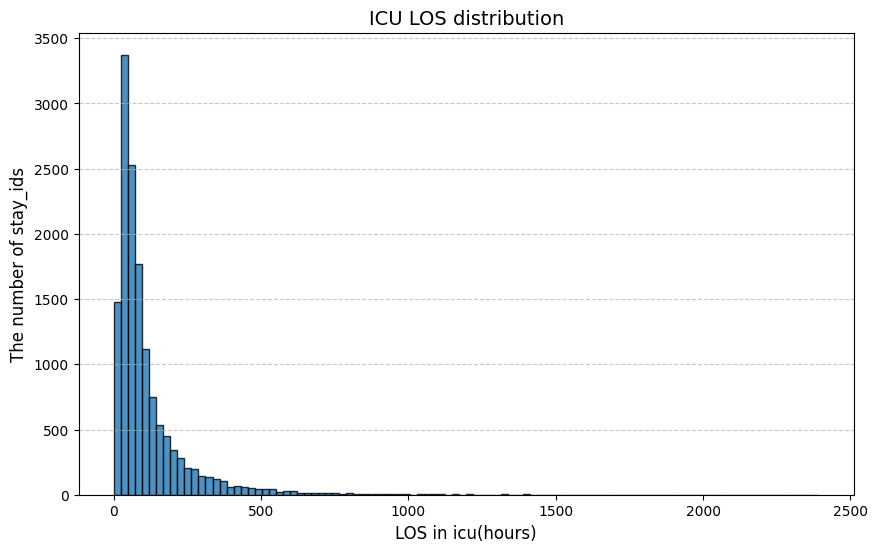

In [166]:
plt.figure(figsize=(10, 6))
plt.hist(updated_df_icustays['los_hours'], bins=100, edgecolor='black', alpha=0.8)
plt.xlabel('LOS in icu(hours)', fontsize=12)
plt.ylabel('The number of stay_ids', fontsize=12)
plt.title('ICU LOS distribution', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [167]:
print("상위 90%: ", np.percentile(updated_df_icustays['los_hours'], 90))
print("상위 95%: ", np.percentile(updated_df_icustays['los_hours'], 95))
print("상위 99%: ", np.percentile(updated_df_icustays['los_hours'], 99))

상위 90%:  253.97847222222222
상위 95%:  362.7211805555556
상위 99%:  695.5868888888888


In [168]:
print("check: ", len(updated_df_icustays[updated_df_icustays['los_hours'] > 1000]))

check:  37


In [256]:
def create_dynamic_hr_timeslots(icustays_df): 
    time_slots_list = []

    for idx, row in icustays_df.iterrows():
        hadm_id = row['hadm_id']
        stay_id = row['stay_id']
        intime = row['intime']
        outtime = row['outtime']

        hour_slot = 0
        slot_start = intime
        while slot_start < outtime: 
            slot_end = slot_start + pd.Timedelta(hours=1)
            time_slots_list.append({
                'hadm_id': hadm_id,
                'stay_id': stay_id,
                'hour_slot': hour_slot,
                'slot_start': slot_start,
                'slot_end': slot_end
            })

            hour_slot += 1
            slot_start = slot_end # 다음 hour slot 시작 시간
    
    time_slots_df = pd.DataFrame(time_slots_list)
    time_slots_df['stay_id'] = time_slots_df['stay_id'].astype('int32')
    return time_slots_df

time_slots_df = create_dynamic_hr_timeslots(key_id_icu)
time_slots_df['hadm_id'] = time_slots_df['hadm_id'].astype(int)

In [186]:
time_slots_df['stay_id'].nunique()

14146

In [187]:
# hadm_stay_counts = intime_df.groupby('hadm_id')['stay_id'].nunique().reset_index()
# multi_stay_hadm_ids = hadm_stay_counts[hadm_stay_counts['stay_id'] > 1]['hadm_id']

In [257]:
# hosp cxr -> icu cxr
intime_df = time_slots_df[time_slots_df['hour_slot'] == 0][['hadm_id', 'stay_id', 'slot_start']]
hosp_cxr_before_icu = hosp_icu_cxr[hosp_icu_cxr['hadm_id'].isin(intime_df['hadm_id'])]
merged_df = hosp_cxr_before_icu.merge(intime_df, on='hadm_id', how='left')

filtered_df = merged_df[
    (merged_df['cxrtime'] >= merged_df['slot_start'] - pd.Timedelta(days=1)) & 
    (merged_df['cxrtime'] < merged_df['slot_start'])
].reset_index(drop=True)

filtered_df['time_diff'] = (filtered_df['slot_start'] - filtered_df['cxrtime']).abs()
filtered_df = filtered_df.sort_values(['hadm_id', 'slot_start', 'time_diff']).reset_index(drop=True)

closest_cxr_df = filtered_df.loc[
    filtered_df.groupby(['hadm_id'])['time_diff'].idxmin()
].reset_index(drop=True)

closest_cxr_df = closest_cxr_df.merge(intime_df, on=['hadm_id', 'slot_start'], how='left')
closest_cxr_df = closest_cxr_df.drop(columns=['stay_id_x', 'stay_id_y'])

In [258]:
test = closest_cxr_df.copy()

In [259]:
closest_cxr_df = closest_cxr_df[['hadm_id', 'stay_id', 'cxrtime', 'Edema', 'Cardiomegaly', 'Pleural Effusion', 'Img_Folder', 'Img_Filename']]
closest_cxr_df = closest_cxr_df.fillna(0)

In [260]:
closest_cxr_df

,hadm_id,stay_id,cxrtime,Edema,Cardiomegaly,Pleural Effusion,Img_Folder,Img_Filename
0,20012254.0,34250019,2171-09-04 09:10:51.718,0.0,0.0,1.0,files/p15/p15457916/s54064261,aabb91d8-f7fd81a7-f50ac78f-4aa49ce3-49bec26e.jpg
1,20020562.0,30253505,2150-08-19 08:38:28.468,0.0,1.0,0.0,files/p19/p19210871/s52238602,0240b411-8ab0e647-bbd00587-ac5ed4cc-cacf2c41.jpg
2,20021612.0,34145253,2162-05-06 19:22:25.406,0.0,0.0,0.0,files/p18/p18549459/s50260240,f0b0b20d-413d3332-3a3ee847-b8a542ca-d5430d7b.jpg
3,20022952.0,39724160,2120-01-24 22:56:55.046,1.0,0.0,0.0,files/p11/p11300581/s59864479,5e3d3f3a-d432079d-704c49a8-c96bea98-3922cb58.jpg
4,20023225.0,35035530,2140-06-30 13:17:05.125,0.0,1.0,0.0,files/p14/p14362539/s55613271,c4c18d33-6d4d1d67-b114fee5-17d16446-8e4239f9.jpg
...,...,...,...,...,...,...,...,...
2566,29967655.0,35646928,2177-10-19 22:24:46.218,0.0,0.0,0.0,files/p18/p18692094/s59297679,5913c585-34d7c3f4-925e08dc-31b95c3e-51ad7d37.jpg
2567,29973313.0,32878949,2155-04-18 22:42:04.593,1.0,0.0,1.0,files/p17/p17854225/s59822995,6064acca-69c0399a-fc413004-7f561672-54c21f46.jpg
2568,29988947.0,38518978,2175-09-02 22:47:29.546,0.0,0.0,0.0,files/p17/p17646651/s51866138,65092dc6-e28f8832-f5759cfd-da7ed52b-1216368a.jpg
2569,29990184.0,38079136,2187-06-19 10:33:24.171,1.0,0.0,1.0,files/p17/p17396346/s51828119,cf843573-ae7cd8aa-c637c215-2d2fa112-c95d2574.jpg


In [261]:
df_merged = closest_cxr_df.merge(df_diag_flags, on='hadm_id', how='left').fillna(False)

C:\Users\gangmin\AppData\Local\Temp\ipykernel_40084\1113617728.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged = closest_cxr_df.merge(df_diag_flags, on='hadm_id', how='left').fillna(False)


In [ ]:
# conditions_supp = [
#     # negative
#     (df_merged['Edema'] == 0),

#     # cardiogenic edema
#     (df_merged['Edema'].isin([1,-1]) & df_merged['has_heart_failure'] & ~ df_merged['has_ards_or_pneumonia']),

#     # non-cardiogenic edema
#     (df_merged['Edema'].isin([1,-1]) & df_merged['has_ards_or_pneumonia'] & ~ df_merged['has_heart_failure']),

#     # cardiogenic edema
#     (df_merged['Edema'].isin([1,-1]) &
#         ((df_merged['Cardiomegaly'] == 1) | (df_merged['Pleural Effusion'] == 1)))
# ]

# values = [0.0, 2.0, 1.0, 2.0]

# df_merged['edema_pathophysiology'] = np.select(conditions_supp, values, default=1.0)

In [175]:
conditions = [
    # 1) Negative
    (df_merged['Edema'] == 0),

    # 2) Cardiogenic edema
    (df_merged['Edema'].isin([1,-1]) & df_merged['has_circulatory'] & ~ df_merged['has_respiratory']),

    # 3) Non-cardiogenic edema
    (df_merged['Edema'].isin([1,-1]) & df_merged['has_respiratory'] & ~ df_merged['has_circulatory']),

    # 4) Re Cardiogenic edema
    (df_merged['Edema'].isin([1,-1]) &
        ((df_merged['Cardiomegaly'] == 1) | (df_merged['Pleural Effusion'] == 1)))
]

values = [0.0, 2.0, 1.0, 2.0]

# More conservative
df_merged['edema_pathophysiology'] = np.select(conditions, values, default=np.nan)

In [263]:
closest_cxr_df = df_merged.copy()

In [264]:
closest_cxr_df[closest_cxr_df['stay_id']==37510196]

,hadm_id,stay_id,cxrtime,Edema,Cardiomegaly,Pleural Effusion,Img_Folder,Img_Filename,has_circulatory,has_respiratory
1570,26184834.0,37510196,2131-01-10 12:54:30.328,1.0,0.0,0.0,files/p10/p10001884/s57156853,9fd47edd-07087209-b901811e-3e9e5f50-f382f611.jpg,True,False


In [265]:
closest_cxr_df[closest_cxr_df['stay_id']==37510196]

,hadm_id,stay_id,cxrtime,Edema,Cardiomegaly,Pleural Effusion,Img_Folder,Img_Filename,has_circulatory,has_respiratory
1570,26184834.0,37510196,2131-01-10 12:54:30.328,1.0,0.0,0.0,files/p10/p10001884/s57156853,9fd47edd-07087209-b901811e-3e9e5f50-f382f611.jpg,True,False


---

## 4.1 Procedure events

In [179]:
# ekg
proc_itemid = [225402, 225794]

In [180]:
proc_list = df_ditems[df_ditems['itemid'].isin(proc_itemid)].reset_index(drop=True)
proc_list

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,225402,EKG,EKG,procedureevents,4-Procedures,None,Processes,NaN,NaN
1,225794,Non-invasive Ventilation,Non-invasive Ventilation,procedureevents,2-Ventilation,None,Processes,NaN,NaN


In [181]:
df_proc

,subject_id,hadm_id,stay_id,starttime,endtime,itemid,value,valueuom,patientweight
0,10001884,26184834,37510196,2131-01-12 21:30:00,2131-01-13 04:00:00,225794,390.0,min,65.0
1,10001884,26184834,37510196,2131-01-12 17:40:00,2131-01-12 17:41:00,227194,1.0,None,65.0
2,10001884,26184834,37510196,2131-01-19 18:44:00,2131-01-19 18:45:00,228128,1.0,None,65.0
3,10001884,26184834,37510196,2131-01-13 16:14:00,2131-01-13 16:15:00,225401,1.0,None,65.0
4,10001884,26184834,37510196,2131-01-13 16:14:00,2131-01-13 16:15:00,225454,1.0,None,65.0
...,...,...,...,...,...,...,...,...,...
215356,19999987,23865745,36195440,2145-11-02 23:28:00,2145-11-02 23:29:00,225966,1.0,None,60.0
215357,19999987,23865745,36195440,2145-11-02 23:34:00,2145-11-04 04:45:00,224277,1751.0,min,60.0
215358,19999987,23865745,36195440,2145-11-02 23:34:00,2145-11-04 07:49:00,224275,1935.0,min,60.0
215359,19999987,23865745,36195440,2145-11-02 23:34:00,2145-11-04 19:15:00,224277,2621.0,min,60.0


In [182]:
def resampling_procedure(procedureevents, time_slots_df):

    """
    Procedure event를 proc_itemid를 한정하여 resampling함.
    이때 procedure이 시행되었는지 여부를 0, 1로 라벨링함.
    """

    procedureevents = procedureevents[procedureevents['itemid'].isin(proc_itemid)]

    procedureevents = procedureevents.drop(columns=['valueuom', 'patientweight'])
    procedureevents = procedureevents.sort_values(by=['stay_id', 'itemid', 'starttime']).reset_index(drop=True)

    binary_results = []

    # Binary 처리
    for idx, row in tqdm(procedureevents.iterrows(), total=len(procedureevents), desc="Processing procedureevents"):
        hadm = row['hadm_id']
        stay = row['stay_id']
        start_time = row['starttime']
        end_time = row['endtime']
        itemid = row['itemid']

        patient_slots = time_slots_df[time_slots_df['stay_id'] == stay].copy()

        overlapping = patient_slots[
            (patient_slots['slot_start'] <= end_time) &
            (patient_slots['slot_end'] > start_time)]
        
        if overlapping.empty:
            continue

        for idx, slotrow in overlapping.iterrows(): 
            binary_results.append({
                'hadm_id': hadm,
                'stay_id': stay,
                'itemid': itemid,
                'hour_slot': slotrow['hour_slot'],
                'slot_start': slotrow['slot_start'],
                'procedure_flag': 1
            })

    binary_results = pd.DataFrame(binary_results).drop_duplicates()
    expanded_results = []

    for itemid in tqdm(proc_itemid, total = len(proc_itemid), desc = "Processing procedureevents"):
        item_slots = time_slots_df.copy()
        item_slots['itemid'] = itemid
        item_slots['procedure_flag'] = 0

        item_data = binary_results[binary_results['itemid']==itemid]
        
        if not item_data.empty:
            item_slots = pd.merge(item_slots, item_data[['stay_id', 'hour_slot', 'procedure_flag']], how='left', on=['stay_id', 'hour_slot'])
            item_slots['procedure_flag'] = item_slots['procedure_flag_y'].fillna(item_slots['procedure_flag_x']).astype(int)
            item_slots = item_slots.drop(columns=['procedure_flag_x', 'procedure_flag_y'])
        expanded_results.append(item_slots)

    processed_df = pd.concat(expanded_results, ignore_index=True)
    return processed_df

In [183]:
sequential_df_proc = resampling_procedure(df_proc, time_slots_df)
sequential_df_proc

Processing procedureevents:   0%|          | 0/12011 [00:00<?, ?it/s]

Processing procedureevents:   0%|          | 0/2 [00:00<?, ?it/s]

,hadm_id,stay_id,hour_slot,slot_start,slot_end,itemid,procedure_flag
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,225402,0
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,225402,0
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,225402,1
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,225402,1
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,225402,0
...,...,...,...,...,...,...,...
3237537,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,225794,0
3237538,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,225794,0
3237539,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,225794,0
3237540,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,225794,0


In [184]:
df_proc[(df_proc['itemid']==225794) & (df_proc['stay_id']==37510196)]

,subject_id,hadm_id,stay_id,starttime,endtime,itemid,value,valueuom,patientweight
0,10001884,26184834,37510196,2131-01-12 21:30:00,2131-01-13 04:00:00,225794,390.0,min,65.0


In [185]:
sequential_df_proc[(sequential_df_proc['itemid']==225794) & (sequential_df_proc['stay_id']==37510196)].iloc[35:50, :]

,hadm_id,stay_id,hour_slot,slot_start,slot_end,itemid,procedure_flag
1618806,26184834,37510196,35,2131-01-12 15:20:05,2131-01-12 16:20:05,225794,0
1618807,26184834,37510196,36,2131-01-12 16:20:05,2131-01-12 17:20:05,225794,0
1618808,26184834,37510196,37,2131-01-12 17:20:05,2131-01-12 18:20:05,225794,0
1618809,26184834,37510196,38,2131-01-12 18:20:05,2131-01-12 19:20:05,225794,0
1618810,26184834,37510196,39,2131-01-12 19:20:05,2131-01-12 20:20:05,225794,0
1618811,26184834,37510196,40,2131-01-12 20:20:05,2131-01-12 21:20:05,225794,0
1618812,26184834,37510196,41,2131-01-12 21:20:05,2131-01-12 22:20:05,225794,1
1618813,26184834,37510196,42,2131-01-12 22:20:05,2131-01-12 23:20:05,225794,1
1618814,26184834,37510196,43,2131-01-12 23:20:05,2131-01-13 00:20:05,225794,1
1618815,26184834,37510196,44,2131-01-13 00:20:05,2131-01-13 01:20:05,225794,1


In [186]:
sequential_df_proc['procedure_flag'].value_counts()

procedure_flag
0    3209523
1      28019
Name: count, dtype: int64

In [ ]:
sequential_df_proc.to_feather(root_dir + '/processed/sequential_df_proc.ftr')

## 4.2 Medication(Inputevents)

In [187]:
# furosemide 250/50 -> furosemide로 통일
df_input.loc[df_input['itemid']==228340, 'itemid'] = 221794

In [188]:
# medication에서는 albumin (220862) 삭제, bumetanide, angiotensin도 삭제 -> chartevent에서 활용함
med_itemid = [221794, 221906, 221662, 221653, 221749, 221986, 222051, 222056, 225168, 225974] 

In [189]:
med_list = df_ditems[df_ditems['itemid'].isin(med_itemid)].reset_index(drop=True)
med_list

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,221653,Dobutamine,Dobutamine,inputevents,Medications,mg,Solution,NaN,NaN
1,221662,Dopamine,Dopamine,inputevents,Medications,mg,Solution,NaN,NaN
2,221749,Phenylephrine,Phenylephrine,inputevents,Medications,mg,Solution,NaN,NaN
3,221794,Furosemide (Lasix),Furosemide (Lasix),inputevents,Medications,mg,Solution,NaN,NaN
4,221906,Norepinephrine,Norepinephrine,inputevents,Medications,mg,Solution,NaN,NaN
5,221986,Milrinone,Milrinone,inputevents,Medications,mg,Solution,NaN,NaN
6,222051,Nitroprusside,Nitroprusside,inputevents,Medications,mg,Solution,NaN,NaN
7,222056,Nitroglycerin,Nitroglycerin,inputevents,Medications,mg,Solution,NaN,NaN
8,225168,Packed Red Blood Cells,PRBC's,inputevents,Blood Products/Colloids,mL,Solution,NaN,NaN
9,225974,Metoprolol,Metoprolol,inputevents,Medications,mg,Solution,NaN,NaN


In [190]:
df_input

,subject_id,hadm_id,stay_id,starttime,endtime,itemid,amount,amountuom,rate,rateuom,patientweight
0,10001884,26184834,37510196,2131-01-18 21:04:00,2131-01-19 02:50:00,222168,798.499966,mg,35.504669,mcg/kg/min,65.0
1,10001884,26184834,37510196,2131-01-18 21:04:00,2131-01-19 02:50:00,225943,79.850000,ml,13.846821,mL/hour,65.0
2,10001884,26184834,37510196,2131-01-19 21:06:00,2131-01-19 21:07:00,225154,1.000000,mg,NaN,None,65.0
3,10001884,26184834,37510196,2131-01-19 21:06:00,2131-01-19 22:30:00,220949,2.800000,ml,2.000000,mL/hour,65.0
4,10001884,26184834,37510196,2131-01-19 21:06:00,2131-01-19 22:30:00,225154,2.800000,mg,2.000000,mg/hour,65.0
...,...,...,...,...,...,...,...,...,...,...,...
2591032,19999987,23865745,36195440,2145-11-02 23:28:00,2145-11-03 09:32:00,225942,0.755000,mg,75.000008,mcg/hour,60.0
2591033,19999987,23865745,36195440,2145-11-02 23:28:00,2145-11-03 09:32:00,225943,15.100000,ml,1.500000,mL/hour,60.0
2591034,19999987,23865745,36195440,2145-11-02 23:38:00,2145-11-03 12:55:00,225158,1000.000000,ml,75.282310,mL/hour,60.0
2591035,19999987,23865745,36195440,2145-11-04 20:35:00,2145-11-04 20:36:00,226452,200.000000,ml,NaN,None,94.0


In [ ]:
# inputevents resampling
def resampling_input(inputevents, time_slots_df): 
    """
    input event를 proc_itemid를 한정하여 resampling함.
    투여량을 시간에 비례하여 분할하여 같은 itemid끼리는 합산하여 시간당 투여량을 계산함.
    """

    inputevents = inputevents[inputevents['itemid'].isin(med_itemid)]

    inputevents = inputevents.drop(columns=['rate', 'rateuom', 'patientweight'])
    inputevents = inputevents.sort_values(by=['stay_id', 'itemid', 'starttime']).reset_index(drop=True)

    med_results = []
    expanded_results = []

    for itemid in tqdm(med_itemid, total=len(med_itemid), desc="Processing inputevents"): 
        item_slots = time_slots_df.copy()
        item_slots['itemid'] = itemid
        # item_slots['input_amount'] = 0.0
        item_slots['input_amount'] = np.nan

        item_data = inputevents[inputevents['itemid'] == itemid]

        for idx, row in item_data.iterrows():
            hadm = row['hadm_id']
            stay = row['stay_id']
            start_time = row['starttime']
            end_time = row['endtime']    
            amount = row['amount']

            patient_slots = time_slots_df[time_slots_df['stay_id']==stay].copy()
            overlapping = patient_slots[(patient_slots['slot_start'] <= end_time) & 
                                        (patient_slots['slot_end'] > start_time)]
            
            if overlapping.empty:
                continue
            
            total_hours = (end_time - start_time).total_seconds() / 3600.0
            if total_hours <= 0: 
                continue

            for idx, slotrow in overlapping.iterrows(): 
                slot_start = slotrow['slot_start']
                slot_end = slotrow['slot_end']

                overlap_start = max(start_time, slot_start)
                overlap_end = min(end_time, slot_end)

                hours_in_slot = (overlap_end - overlap_start).total_seconds() / 3600.0
                if hours_in_slot < 0: 
                    hours_in_slot = 0

                amount_per_slot = amount * (hours_in_slot / total_hours)

                existing = next(
                    (
                        result for result in med_results
                        if result['stay_id'] == stay
                        and result['itemid'] == itemid
                        and result['hour_slot'] == slotrow['hour_slot']  
                    ),
                    None,
                )

                if existing: 
                    existing['input_amount'] += amount_per_slot
                    
                else: 
                    med_results.append({
                        'hadm_id': hadm,
                        'stay_id': stay,
                        'itemid': itemid,
                        'hour_slot': slotrow['hour_slot'],
                        'slot_start': slotrow['slot_start'],
                        'input_amount': amount_per_slot
                    })

        item_data_df = pd.DataFrame(med_results)
        item_data_df = item_data_df[item_data_df['itemid'] == itemid]

        if not item_data_df.empty: 
            item_slots = pd.merge(item_slots, item_data_df[['stay_id', 'hour_slot', 'input_amount']], how='left', on = ['stay_id', 'hour_slot'])
            # item_slots['input_amount'] = item_slots['input_amount_y'].fillna(item_slots['input_amount_x'])
            # item_slots = item_slots.drop(columns=['input_amount_x', 'input_amount_y'])

            # no zero imputation, 결측 행 nan으로 처리
            item_slots['input_amount'] = item_slots['input_amount_y'].combine_first(item_slots['input_amount_x'])
            item_slots = item_slots.drop(columns=['input_amount_x', 'input_amount_y'])

        expanded_results.append(item_slots)

    processed_df = pd.concat(expanded_results, ignore_index=True)
    return processed_df

In [ ]:
sequential_df_med = resampling_input(df_input, time_slots_df)
sequential_df_med

In [ ]:
sequential_df_med['input_amount'].isnull().sum()

15675055

In [ ]:
test = sequential_df_med.copy()

In [ ]:
sequential_df_med['input_amount'] = sequential_df_med['input_amount'].apply(lambda x: round(x, 3))

In [ ]:
sequential_df_med.to_feather(root_dir + '/processed/sequential_df_med.ftr')

## 4.3 Chart events

In [193]:
itemid_map = {
    50862:227456, 52022:227456, 53085:227456, 53138:227456,         # albumin
    50983:220645, 52623:220645, 50824:220645, 52455:220645,         # sodium
    51006:225624, 52647:225624,                                     # bun
    50868:227073, 52500:227073,                                     # anion gap
    51003:227429,                                                   # troponin-t
    50971:227442, 52610:227442, 50822:227442, 52452:227442,         # potassium
    50816:223835,                                                   # fio2
    50963:50963,                                                    # NTproBNP
    50911:227445                                                    # CK-MB
}

In [194]:
bakcup_df_lab = df_lab.copy()

In [195]:
def get_ward_lab_before_icu_admission(df_lab, time_slots_df, itemid_map):
    valid_itemids = set(itemid_map.keys())
    df_lab = df_lab[df_lab['itemid'].isin(valid_itemids)]

    icu_start_df = time_slots_df[time_slots_df['hour_slot'] == 0][['stay_id', 'hadm_id', 'slot_start']]
    df_lab = df_lab.merge(icu_start_df, on='hadm_id', how='inner')
    
    df_lab = df_lab[
        (df_lab['charttime'] >= df_lab['slot_start'] - pd.Timedelta(hours=24)) &
        (df_lab['charttime'] < df_lab['slot_start'])
    ].copy()
    
    # itemid 변환 (Lab -> ICU)
    df_lab['itemid'] = df_lab['itemid'].map(itemid_map)
    df_lab['time_diff'] = (df_lab['slot_start'] - df_lab['charttime']).abs()
    
    # ICU T=0 slot으로 할당할 값 남기기
    closest = df_lab.loc[df_lab.groupby(['stay_id', 'itemid'])['time_diff'].idxmin()].copy()
    closest['hour_slot'] = 0
    return closest[['stay_id', 'itemid', 'hour_slot', 'slot_start', 'valuenum']].rename(columns={'valuenum': 'value'})

In [196]:
df_ward_T0 = get_ward_lab_before_icu_admission(df_lab, time_slots_df, itemid_map)
df_ward_T0

,stay_id,itemid,hour_slot,slot_start,value
278033,30000646,220645,0,2194-04-29 01:39:22,137.00
278034,30000646,225624,0,2194-04-29 01:39:22,11.00
278031,30000646,227073,0,2194-04-29 01:39:22,12.00
278032,30000646,227442,0,2194-04-29 01:39:22,4.00
717012,30001947,220645,0,2162-12-26 15:04:30,143.00
...,...,...,...,...,...
722823,39996044,227429,0,2164-12-10 17:50:47,0.01
1074520,39998622,220645,0,2135-02-11 18:13:55,138.00
1074522,39998622,225624,0,2135-02-11 18:13:55,16.00
1074516,39998622,227073,0,2135-02-11 18:13:55,17.00


In [197]:
df_ward_T0['itemid'].unique()

array([220645, 225624, 227073, 227442, 227456, 223835, 227429, 227445,
        50963], dtype=int64)

In [198]:
def assign_stayid_to_lab(df_lab, time_slots_df, itemid_map):
    valid_itemids = set(itemid_map.keys())
    df_lab = df_lab[df_lab['itemid'].isin(valid_itemids)].copy()

    icu_min_time = time_slots_df['slot_start'].min()
    df_lab = df_lab[df_lab['charttime'] >= icu_min_time].copy()

    icu_stay_ranges = time_slots_df[['stay_id', 'hadm_id', 'slot_start']].copy()
    icu_stay_ranges = icu_stay_ranges.groupby('stay_id').agg(
        hadm_id=('hadm_id', 'first'),
        intime=('slot_start', 'min'),
        outtime=('slot_start', 'max')
    ).reset_index()
    icu_stay_ranges['outtime'] += pd.Timedelta(hours=1)  # slot_end 보정

    # 병동 lab 데이터에 ICU stay_id 할당
    df_lab = df_lab.copy()
    df_lab['stay_id'] = None

    for _, row in tqdm(icu_stay_ranges.iterrows(), total=len(icu_stay_ranges), desc="Assigning stay_id to lab rows"):
        mask = (
            (df_lab['hadm_id'] == row['hadm_id']) &
            (df_lab['charttime'] >= row['intime']) &
            (df_lab['charttime'] < row['outtime'])
        )
        df_lab.loc[mask, 'stay_id'] = row['stay_id']
    return df_lab[df_lab['stay_id'].notnull()].copy()

In [199]:
stayid_with_lab = assign_stayid_to_lab(df_lab, time_slots_df, itemid_map)

Assigning stay_id to lab rows:   0%|          | 0/14146 [00:00<?, ?it/s]

In [200]:
def get_ward_lab_within_icu_stay(df_lab, time_slots_df, itemid_map):
    df_lab = df_lab[df_lab['itemid'].isin(itemid_map.keys())].copy()
    df_lab['itemid'] = df_lab['itemid'].map(itemid_map) # mapping

    time_slots_df = time_slots_df.copy()
    time_slots_df['slot_end'] = time_slots_df['slot_start'] + pd.Timedelta(hours=1)

    # 병동 lab을 ICU 시간 슬롯에 할당
    merged = pd.merge_asof(
        df_lab.sort_values('charttime'),
        time_slots_df.sort_values('slot_start'),
        by='stay_id',
        left_on='charttime',
        right_on='slot_start',
        direction='backward' # 과거 시점만 허용함.
    )

    merged = merged[
        (merged['charttime'] >= merged['slot_start']) &
        (merged['charttime'] < merged['slot_end'])
    ]

    # time slot별 평균
    grouped = merged.groupby(['stay_id', 'itemid', 'hour_slot', 'slot_start']) \
                    .agg(value=('valuenum', 'mean')) \
                    .reset_index()
    return grouped

In [201]:
stayid_with_lab['stay_id'] = stayid_with_lab['stay_id'].astype(int)

In [202]:
labs_during_icu = get_ward_lab_within_icu_stay(stayid_with_lab, time_slots_df, itemid_map)
labs_during_icu

,stay_id,itemid,hour_slot,slot_start,value
0,30000646,220645,0,2194-04-29 01:39:22,138.0
1,30000646,220645,4,2194-04-29 05:39:22,141.0
2,30000646,220645,17,2194-04-29 18:39:22,143.0
3,30000646,220645,27,2194-04-30 04:39:22,140.0
4,30000646,220645,55,2194-05-01 08:39:22,140.0
...,...,...,...,...,...
557219,39998622,227442,189,2135-02-19 15:13:55,3.7
557220,39998622,227442,201,2135-02-20 03:13:55,4.2
557221,39998622,227442,212,2135-02-20 14:13:55,3.9
557222,39998622,227456,32,2135-02-13 02:13:55,2.9


In [203]:
time_slots_df['stay_id'] = time_slots_df['stay_id'].astype(int)

In [204]:
# temperature 단위 변환은 완료했으니 하나로 통일
df_chart['itemid'] = df_chart['itemid'].replace({223762:223761})

chart_itemid = [220045, 220179, 220180, 220277, 220210, 227429, 227446, 225624, 227073, 223761, 220645, 227442, 223835, 227456, 227445]

In [205]:
chart_list = df_ditems[df_ditems['itemid'].isin(chart_itemid)].reset_index(drop=True)
chart_list

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,220045,Heart Rate,HR,chartevents,Routine Vital Signs,bpm,Numeric,NaN,NaN
1,220179,Non Invasive Blood Pressure systolic,NBPs,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
2,220180,Non Invasive Blood Pressure diastolic,NBPd,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
3,220210,Respiratory Rate,RR,chartevents,Respiratory,insp/min,Numeric,NaN,NaN
4,220277,O2 saturation pulseoxymetry,SpO2,chartevents,Respiratory,%,Numeric,NaN,NaN
5,220645,Sodium (serum),Sodium (serum),chartevents,Labs,None,Numeric,NaN,NaN
6,223761,Temperature Fahrenheit,Temperature F,chartevents,Routine Vital Signs,°F,Numeric,NaN,NaN
7,223835,Inspired O2 Fraction,FiO2,chartevents,Respiratory,None,Numeric,NaN,NaN
8,225624,BUN,BUN,chartevents,Labs,None,Numeric,NaN,NaN
9,227073,Anion gap,Anion gap,chartevents,Labs,None,Numeric,NaN,NaN


In [206]:
def resampling_chart(chartevents, time_slots_df):
    chartevents = chartevents[chartevents['itemid'].isin(chart_itemid)]
    chartevents = chartevents.sort_values(by=['stay_id', 'itemid', 'charttime']).reset_index(drop=True)

    time_slots_df['slot_end'] = time_slots_df['slot_start'] + pd.Timedelta(hours=1)

    merged = pd.merge_asof(
        chartevents.sort_values('charttime'),
        time_slots_df.sort_values('slot_start'),
        by='stay_id',
        left_on='charttime',
        right_on='slot_start',
        direction='backward'
    )

    merged = merged[(merged['charttime'] >= merged['slot_start']) & (merged['charttime'] < merged['slot_end'])]

    grouped = (
        merged.groupby(['stay_id', 'itemid', 'hour_slot', 'slot_start'])
        .agg(value_sum=('valuenum', 'sum'), value_count=('valuenum', 'count'))
        .reset_index()
    )

    grouped['value'] = grouped['value_sum'] / grouped['value_count']

    all_slots = time_slots_df.copy()
    all_slots = all_slots.assign(key=1)  # Cartesian Product를 위해 key 추가
    items_df = pd.DataFrame({'itemid': chart_itemid, 'key': 1}) 
    full_slots = pd.merge(all_slots, items_df, on='key').drop(columns=['key'])

    final_result = pd.merge(
        full_slots,
        grouped,
        on=['stay_id', 'hour_slot', 'slot_start', 'itemid'],
        how='left'
    )

    final_result = final_result.sort_values(['stay_id', 'itemid', 'slot_start']).reset_index(drop=True)
    return final_result.drop(columns=['value_sum', 'value_count'], errors='ignore')

In [207]:
sequential_df_chart = resampling_chart(df_chart, time_slots_df)

In [241]:
fio2_df = sequential_df_chart[sequential_df_chart['itemid']==223835]
fio2_df[fio2_df['value'] < 0]

,hadm_id,stay_id,hour_slot,slot_start,slot_end,itemid,value


In [208]:
check = sequential_df_chart[sequential_df_chart['itemid']==227446]
check['value'].max()

67806.89999999992

In [219]:
sequential_df_chart.to_feather(root_dir + '/processed/sequential_df_chart.ftr')

| 이름          | 내용                                                                 | 생성 방법                        |
|---------------|----------------------------------------------------------------------|----------------------------------|
| `sequential_df_chart`    | ICU stay 중 chart events를 `slot_start` 기준으로 리샘플링한 시계열      | `resampling_chart()`             |
| `df_ward_T0`  | ICU 입실 전 24시간 내 병동 lab 중 가장 최근값을 T=0 slot에 할당         | `get_ward_lab_before_icu_admission()` |
| `df_ward_icu` | ICU stay 중 charttime이 ICU 체류 구간에 포함되는 병동 lab 값을 각 slot에 할당 | `get_ward_lab_within_icu_stay()` |

In [209]:
df_ntprobnp_during_icu = labs_during_icu[labs_during_icu['itemid']==50963].sort_values(['stay_id', 'hour_slot']).reset_index(drop=True)
df_ntprobnp_ward_t0 = df_ward_T0[df_ward_T0['itemid']==50963].sort_values(['stay_id', 'hour_slot']).reset_index(drop=True)
df_ntprobnp = pd.concat([df_ntprobnp_during_icu, df_ntprobnp_ward_t0], ignore_index=True)

df_ntprobnp_slots = time_slots_df[['stay_id', 'hour_slot', 'slot_start']]
df_ntprobnp_slots.loc[:, 'itemid'] = 50963

C:\Users\gangmin\AppData\Local\Temp\ipykernel_40084\2587763442.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ntprobnp_slots.loc[:, 'itemid'] = 50963


In [210]:
df_ntprobnp = df_ntprobnp.drop_duplicates(subset=['stay_id', 'itemid', 'hour_slot'])

In [211]:
df_ntprobnp_full = pd.merge(
    df_ntprobnp_slots,
    df_ntprobnp,
    on=['stay_id', 'hour_slot', 'itemid'],
    how='left'
)

df_ntprobnp_full = df_ntprobnp_full.drop(columns=['slot_start_y'])
df_ntprobnp_full = df_ntprobnp_full.rename(columns={'slot_start_x': 'slot_start'})

In [212]:
# 1128
df_ntprobnp_full[df_ntprobnp_full['value'] > 0]

,stay_id,hour_slot,slot_start,itemid,value
774,32128372,0,2137-02-25 23:37:19,50963,1903.0
1155,38383343,0,2137-08-17 17:36:37,50963,7441.0
1237,38383343,82,2137-08-21 03:36:37,50963,10142.0
1738,31921355,4,2136-04-22 22:01:13,50963,1405.0
2119,37153661,35,2166-02-13 03:03:00,50963,1737.0
...,...,...,...,...,...
1610554,37645530,0,2136-01-09 22:08:20,50963,1261.0
1611252,30159100,126,2152-09-19 01:09:18,50963,783.0
1612298,39986786,117,2145-02-25 11:27:00,50963,1516.0
1616684,35505750,59,2185-11-05 13:00:00,50963,16141.0


In [213]:
def merge_chart_and_ward_sources_with_aggregation(sequential_df_chart, df_ward_T0, labs_during_icu):
    df_ward_T0 = df_ward_T0[df_ward_T0['itemid'] != 50963]
    labs_during_icu = labs_during_icu[labs_during_icu['itemid'] != 50963]
    
    all_sources = pd.concat([sequential_df_chart, df_ward_T0, labs_during_icu], ignore_index=True)
    merged = all_sources.groupby(['stay_id', 'itemid', 'hour_slot', 'slot_start'], as_index=False).agg(value=('value', 'mean'))
    return merged

In [214]:
print("기존 df_chart 결측행:", sequential_df_chart['value'].isnull().sum())

기존 df_chart 결측행: 16465061


In [215]:
# main chart processed df
merged = merge_chart_and_ward_sources_with_aggregation(sequential_df_chart, df_ward_T0, labs_during_icu)

In [216]:
lab_imputed_chart = pd.concat([merged, df_ntprobnp_full], ignore_index=True)

In [217]:
lab_imputed_chart['itemid'].nunique()

16

In [218]:
lab_imputed_chart[lab_imputed_chart['itemid']==50963].sort_values(['stay_id', 'hour_slot'])

,stay_id,itemid,hour_slot,slot_start,value
24647050,30000646,50963,0,2194-04-29 01:39:22,NaN
24647051,30000646,50963,1,2194-04-29 02:39:22,NaN
24647052,30000646,50963,2,2194-04-29 03:39:22,NaN
24647053,30000646,50963,3,2194-04-29 04:39:22,NaN
24647054,30000646,50963,4,2194-04-29 05:39:22,NaN
...,...,...,...,...,...
25745460,39998622,50963,211,2135-02-20 13:13:55,NaN
25745461,39998622,50963,212,2135-02-20 14:13:55,NaN
25745462,39998622,50963,213,2135-02-20 15:13:55,NaN
25745463,39998622,50963,214,2135-02-20 16:13:55,NaN


In [219]:
lab_imputed_chart['itemid'].value_counts()

itemid
220045    1618771
220179    1618771
220180    1618771
220210    1618771
220277    1618771
220645    1618771
223761    1618771
223835    1618771
225624    1618771
227073    1618771
227429    1618771
227442    1618771
227445    1618771
227446    1618771
227456    1618771
50963     1618771
Name: count, dtype: int64

In [220]:
df_ward_T0[(df_ward_T0['stay_id']==39998622) & (df_ward_T0['itemid']==227442)]

,stay_id,itemid,hour_slot,slot_start,value
1074518,39998622,227442,0,2135-02-11 18:13:55,4.7


In [221]:
labs_during_icu[(labs_during_icu['stay_id']==39998622) & (labs_during_icu['itemid']==227442)].head(20)

,stay_id,itemid,hour_slot,slot_start,value
557205,39998622,227442,0,2135-02-11 18:13:55,5.1
557206,39998622,227442,8,2135-02-12 02:13:55,5.0
557207,39998622,227442,23,2135-02-12 17:13:55,4.9
557208,39998622,227442,32,2135-02-13 02:13:55,4.7
557209,39998622,227442,55,2135-02-14 01:13:55,4.5
557210,39998622,227442,69,2135-02-14 15:13:55,4.4
557211,39998622,227442,79,2135-02-15 01:13:55,4.1
557212,39998622,227442,94,2135-02-15 16:13:55,4.2
557213,39998622,227442,103,2135-02-16 01:13:55,4.1
557214,39998622,227442,118,2135-02-16 16:13:55,3.9


In [222]:
lab_imputed_chart[(lab_imputed_chart['stay_id']==39998622) & (lab_imputed_chart['itemid']==227442)].head(20)

,stay_id,itemid,hour_slot,slot_start,value
24280701,39998622,227442,0,2135-02-11 18:13:55,4.966667
24280702,39998622,227442,1,2135-02-11 19:13:55,NaN
24280703,39998622,227442,2,2135-02-11 20:13:55,NaN
24280704,39998622,227442,3,2135-02-11 21:13:55,NaN
24280705,39998622,227442,4,2135-02-11 22:13:55,NaN
24280706,39998622,227442,5,2135-02-11 23:13:55,NaN
24280707,39998622,227442,6,2135-02-12 00:13:55,NaN
24280708,39998622,227442,7,2135-02-12 01:13:55,NaN
24280709,39998622,227442,8,2135-02-12 02:13:55,5.000000
24280710,39998622,227442,9,2135-02-12 03:13:55,NaN


In [245]:
fio2_df = lab_imputed_chart[lab_imputed_chart['itemid']==223835]
fio2_df[fio2_df['value'] < 0]

,stay_id,itemid,hour_slot,slot_start,value


In [242]:
lab_imputed_chart.to_feather(root_dir + '/processed/lab_imputed_chart_before_ffill.ftr')

## 4.4 Output events

In [ ]:
df_urine = df_urine[df_urine['urine'] > 0]
df_urine = df_urine[['hadm_id', 'stay_id', 'starttime', 'endtime', 'urine']]
df_urine = df_urine.sort_values(by=['stay_id', 'starttime']).reset_index(drop=True)

In [ ]:
def resampling_output(df_urine, time_slots_df):

    merged = pd.merge(
        df_urine,
        time_slots_df,
        on='stay_id',
        how='inner'
    )

    merged['overlap_start'] = merged[['starttime', 'slot_start']].max(axis=1)
    merged['overlap_end'] = merged[['endtime', 'slot_end']].min(axis=1)
    merged['overlap_hours'] = (merged['overlap_end'] - merged['overlap_start']).dt.total_seconds() / 3600.0

    merged = merged[(merged['overlap_hours'] > 0)]

    total_hours = (merged['endtime'] - merged['starttime']).dt.total_seconds() / 3600.0
    merged['urine_output'] = merged['urine'] * (merged['overlap_hours'] / total_hours)

    grouped = merged.groupby(['stay_id', 'hour_slot'], as_index=False)['urine_output'].sum()

    processed_df = pd.merge(
        time_slots_df,
        grouped,
        on=['stay_id', 'hour_slot'],
        how='left'
    )
    # processed_df['urine_output'] = processed_df['urine_output'].fillna(0)
    return processed_df

In [ ]:
sequential_df_output = resampling_output(df_urine, time_slots_df)
# sequential_df_output.to_feather(root_dir + '/processed/sequential_df_output.ftr')

- 다 잘 된거 같으면 chart, input, output sequential_df 저장하기

In [ ]:
sequential_df_output

,hadm_id,stay_id,hour_slot,slot_start,slot_end,urine_output
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,NaN
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,NaN
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,92.048611
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,215.296022
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,123.782818
...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,NaN
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,NaN
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,303.333333
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,21.666667


## 4.5 CXR (Image modality)

In [266]:
df_cxr['edema_pathophysiology'].value_counts()

edema_pathophysiology
0.0    39700
2.0    14247
1.0     1691
Name: count, dtype: int64

In [268]:
labeling = df_cxr[['stay_id', 'cxrtime', 'Edema']]
labeling

,stay_id,cxrtime,Edema
0,37510196.0,2131-01-15 04:45:09.078,0.0
1,37510196.0,2131-01-12 04:56:56.359,1.0
2,37510196.0,2131-01-13 04:49:18.484,1.0
3,37510196.0,2131-01-14 10:34:28.765,-1.0
4,35479615.0,2156-05-18 02:47:37.203,1.0
...,...,...,...
57909,35165301.0,2197-08-07 09:06:37.796,0.0
57910,35165301.0,2197-08-05 09:37:46.343,0.0
57911,32336619.0,2148-11-19 22:47:03.375,0.0
57912,36195440.0,2145-11-04 05:14:48.218,0.0


In [ ]:
# 결측 라벨 2276개 발생
labeling['edema_pathophysiology'].isnull().sum()

2276

In [145]:
labeling.to_feather(root_dir + '/processed/labeling.ftr')

In [271]:
# 동일한 time_slot 내 중복 cxr 확인
check_duplicate_cxrtime = df_cxr[['stay_id', 'cxrtime']]
merged = pd.merge(check_duplicate_cxrtime, time_slots_df, on='stay_id', how='inner')
merged = merged[
    (merged['cxrtime'] >= merged['slot_start']) & 
    (merged['cxrtime'] < merged['slot_start'] + pd.Timedelta(hours=1))
]
duplicate_cxr = (merged.groupby(['stay_id', 'hour_slot']).size().reset_index(name='count').query('count > 1'))

In [272]:
# 한 번의 촬영에서 여러 이미지의 촬영을 가진 환자가 많음. -> 과연 어떤 이미지를 고르는 것이 현명할까?
print("동일한 time slot에 촬영 이미지가 2회 이상인 stay_id 수: ", len(duplicate_cxr[duplicate_cxr['count'] >= 2]))
print("동일한 time slot에 촬영 이미지가 3회 이상인 stay_id 수: ", len(duplicate_cxr[duplicate_cxr['count'] >= 3]))

동일한 time slot에 촬영 이미지가 2회 이상인 stay_id 수:  6075
동일한 time slot에 촬영 이미지가 3회 이상인 stay_id 수:  607


In [275]:
# time slot에 cxr 할당
## 일단 중복될 경우 첫 번째 이미지를 할당하는 것으로, 나머지 이미지는 버리는 것으로 함.
def assign_cxr_to_slots(cxr, time_slots_df): 
    cxr_sorted = cxr.sort_values(by=['stay_id', 'cxrtime'])
    merged = pd.merge(cxr_sorted, time_slots_df, on='stay_id', how='inner')

    merged = merged[
        (merged['cxrtime'] >= merged['slot_start']) & 
        (merged['cxrtime'] < merged['slot_start'] + pd.Timedelta(hours=1))
    ]

    merged = merged.sort_values(by=['stay_id', 'hour_slot', 'cxrtime']).drop_duplicates(subset=['stay_id', 'hour_slot'], keep='last')

    all_slots = time_slots_df.copy()
    all_slots['cxr_flag'] = 0
    all_slots['image_path'] = np.nan

    all_slots = pd.merge(all_slots, merged[['stay_id', 'hour_slot', 'Img_Folder', 'Img_Filename', 'cxrtime', 'Edema']], 
                        on = ['stay_id', 'hour_slot'], how='left'
                        )

    all_slots['cxr_flag'] = all_slots['Img_Folder'].notna().astype(int)
    all_slots['image_path'] = all_slots.apply(lambda row: f"{row['Img_Folder']}/{row['Img_Filename']}" if row['cxr_flag'] == 1 else None, axis=1)
    processed_df = all_slots.drop(columns=['Img_Folder', 'Img_Filename'])
    return processed_df

In [276]:
sequential_df_cxr = assign_cxr_to_slots(df_cxr, time_slots_df)
sequential_df_cxr

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,Edema
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,0,None,NaT,NaN
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,0,None,NaT,NaN
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,0,None,NaT,NaN
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,0,None,NaT,NaN
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,0,None,NaT,NaN
...,...,...,...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,0,None,NaT,NaN
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,0,None,NaT,NaN
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,0,None,NaT,NaN
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,0,None,NaT,NaN


| Old Label Distribution        | num         |
|---------------|--------------------------|
| 0.0    | 34879 |
| 2.0  | 11759 |
| 1.0 | 4371 |

In [ ]:
# New
sequential_df_cxr['edema_pathophysiology'].value_counts()

edema_pathophysiology
0.0    34879
2.0    12626
1.0     1522
Name: count, dtype: int64

In [277]:
sequential_df_cxr['Edema'].value_counts()

Edema
 0.0    34879
 1.0    11856
-1.0     4274
Name: count, dtype: int64

In [278]:
sequential_df_cxr.to_feather(root_dir + '/processed/sequential_df_cxr_edema_label.ftr')

In [279]:
closest_cxr_df['cxr_flag'] = 0
closest_cxr_df['cxr_flag'] = closest_cxr_df['Img_Folder'].notna().astype(int)
closest_cxr_df['image_path'] = closest_cxr_df.apply(lambda row: f"{row['Img_Folder']}/{row['Img_Filename']}" if row['cxr_flag'] == 1 else None, axis=1)
closest_cxr_df = closest_cxr_df.drop(columns=['Img_Folder', 'Img_Filename'])

In [282]:
def impute_cxr_with_mask(df, hosp_cxr_closest):
    df = df.copy()
    target_rows = df[(df['hour_slot'] == 0) & (df['cxr_flag'] == 0)].copy()

    for idx in tqdm(target_rows.index, desc="Imputing cxr data"):
        stay_id = df.loc[idx, 'stay_id']
        
        if pd.isna(stay_id): 
            continue

        filtered_rows = hosp_cxr_closest[hosp_cxr_closest['stay_id'] == stay_id]

        if filtered_rows.empty:
            continue

        closest_row = filtered_rows.iloc[0]

        df.loc[idx, 'cxr_flag'] = 1
        df.loc[idx, 'image_path'] = closest_row['image_path']
        df.loc[idx, 'cxrtime'] = closest_row['cxrtime']
        # df.loc[idx, 'edema_pathophysiology'] = closest_row['edema_pathophysiology']
        df.loc[idx, 'Edema'] = closest_row['Edema']
        df.loc[idx, 'was_missing'] = 1

    df.loc[df['cxr_flag'] == 0, 'was_missing'] = 0
    df.loc[df['cxr_flag'] == 1, 'was_missing'] = 1
    return df

In [283]:
imputed_cxr_df = impute_cxr_with_mask(sequential_df_cxr, closest_cxr_df)

Imputing cxr data:   0%|          | 0/12482 [00:00<?, ?it/s]

In [ ]:
imputed_cxr_df['edema_pathophysiology'].value_counts()

edema_pathophysiology
0.0    36390
2.0    13222
1.0     1594
Name: count, dtype: int64

In [ ]:
imputed_cxr_df['edema_pathophysiology'].isnull().sum()

1567565

In [284]:
imputed_cxr_df['Edema'].value_counts()

Edema
 0.0    36390
 1.0    12411
-1.0     4496
Name: count, dtype: int64

In [285]:
imputed_cxr_df['Edema'].isnull().sum()

1565474

- cxr imputation의 차이를 보여줌

In [155]:
sequential_df_cxr[sequential_df_cxr['stay_id']==37510196].head()

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,edema_pathophysiology
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,0,None,NaT,NaN
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,0,None,NaT,NaN
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,0,None,NaT,NaN
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,0,None,NaT,NaN
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,0,None,NaT,NaN


In [156]:
imputed_cxr_df.head()

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,edema_pathophysiology,was_missing
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,1,files/p10/p10001884/s57156853/9fd47edd-0708720...,2131-01-10 12:54:30.328,2.0,1.0
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,0,None,NaT,NaN,0.0
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,0,None,NaT,NaN,0.0
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,0,None,NaT,NaN,0.0
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,0,None,NaT,NaN,0.0


In [287]:
print(f'lab CXR 보간 이전: {sequential_df_cxr.image_path.nunique()}')

lab CXR 보간 이전: 51009


In [288]:
print(f'lab CXR 보간 이후: {imputed_cxr_df.image_path.nunique()}')

lab CXR 보간 이후: 53228


In [289]:
imputed_cxr_df.to_feather(root_dir + '/processed/imputed_cxr_df_0220.ftr')

## 4.6 radiology report(Text modality)

In [ ]:
gc.collect()

27

In [ ]:
# # bioclinicalBERT tokenizer 사용함.
# import re
# from transformers import AutoTokenizer, AutoModel
# tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
# model = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

c:\Users\gangmin\AppData\Local\miniconda3\envs\clip\lib\site-packages\huggingface_hub\file_download.py:147: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\gangmin\.cache\huggingface\hub\models--emilyalsentzer--Bio_ClinicalBERT. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

- radiology report에 결측된 hadm_id 할당, stay_id 열 신설하여 할당
- key_id_static에 있는 환자만 사용할 수 있도록 수정함.

In [ ]:
rad_report = pd.read_parquet("C:/Users/gangmin/dahs/data/mimic-iv-note-deidentified-free-text-clinical-notes-2.2/note/radiology.parquet")
rad_report['charttime'] = pd.to_datetime(rad_report['charttime'])
rad_report = rad_report[['subject_id', 'hadm_id', 'charttime', 'text']]
rad_report = rad_report.rename(columns={'charttime': 'rad_time'})

In [ ]:
rad_report

,subject_id,hadm_id,rad_time,text
0,10000032,22595853.0,2180-05-06 21:19:00,EXAMINATION: CHEST (PA AND LAT)\n\nINDICATION...
1,10000032,22595853.0,2180-05-06 23:00:00,EXAMINATION: LIVER OR GALLBLADDER US (SINGLE ...
2,10000032,22595853.0,2180-05-07 09:55:00,"INDICATION: ___ HCV cirrhosis c/b ascites, hi..."
3,10000032,NaN,2180-06-03 12:46:00,EXAMINATION: Ultrasound-guided paracentesis.\...
4,10000032,NaN,2180-07-08 13:18:00,EXAMINATION: Paracentesis\n\nINDICATION: ___...
...,...,...,...,...
2321350,19999987,23865745.0,2145-11-02 22:37:00,"HISTORY: ___, with left occipital bleeding. ..."
2321351,19999987,23865745.0,2145-11-03 04:35:00,INDICATION: ___ female intubated for head ble...
2321352,19999987,23865745.0,2145-11-03 16:40:00,HISTORY: ___ woman with left occipital hemorr...
2321353,19999987,23865745.0,2145-11-04 05:10:00,PORTABLE CHEST OF ___\n\nCOMPARISON: ___ radi...


In [ ]:
# static info 외의 report 삭제
subject_ids = key_id_static['subject_id'].unique()
rad_report = rad_report[rad_report['subject_id'].isin(subject_ids)].reset_index(drop=True)

In [ ]:
key_id_static.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14146 entries, 0 to 14145
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   subject_id          14146 non-null  int32         
 1   hadm_id             14146 non-null  int32         
 2   stay_id             14146 non-null  float64       
 3   admittime           14146 non-null  datetime64[ns]
 4   dischtime           14146 non-null  datetime64[ns]
 5   edregtime           11048 non-null  object        
 6   edouttime           11048 non-null  object        
 7   intime              14146 non-null  datetime64[ns]
 8   outtime             14146 non-null  datetime64[ns]
 9   los                 14146 non-null  float64       
 10  admission_type      14146 non-null  object        
 11  admission_location  14146 non-null  object        
 12  discharge_location  14101 non-null  object        
 13  insurance           14146 non-null  object    

In [ ]:
# report hadm_id 할당 함수
def assign_report_hadm_id(row, df):
    hadm_records = df[df['subject_id'] == row['subject_id']]
    for idx, record in hadm_records.iterrows():
        if record['admittime'] <= row['rad_time'] <= record['dischtime']:
            return record['hadm_id']
    return None

# report stay_id 할당 함수
def assign_report_stay_id(row, icu_in_out):
    stay_records = icu_in_out[(icu_in_out['subject_id'] == row['subject_id']) & (icu_in_out['hadm_id']==row['hadm_id'])]
    for idx, record in stay_records.iterrows():
        if record['intime'] <= row['rad_time'] <= record['outtime']:
            return record['stay_id']
    return None

rad_report['hadm_id'] = rad_report.apply(lambda row: assign_report_hadm_id(row, key_id_static), axis=1)
rad_report['stay_id'] = rad_report.apply(lambda row: assign_report_stay_id(row, key_id_static), axis=1)

In [ ]:
print(rad_report['hadm_id'].isnull().sum())
print(rad_report['stay_id'].isnull().sum())

206320
245326


In [ ]:
total_report = rad_report

In [ ]:
impore re

In [ ]:
rad_report = rad_report.dropna(subset=['hadm_id', 'stay_id']).reset_index(drop=True)

In [ ]:
# text는 findings와 impression만 추출해서 사용함.
def extract_findings_and_impressions(text):
    findings = re.search(r"FINDINGS:(.*?)(IMPRESSION:|$)", text, re.DOTALL | re.IGNORECASE)
    impressions = re.search(r"IMPRESSION:(.*)", text, re.DOTALL | re.IGNORECASE)
    
    findings_text = findings.group(1).strip() if findings else ""
    impressions_text = impressions.group(1).strip() if impressions else ""
    
    return findings_text + " " + impressions_text

rad_report['extracted_text'] = rad_report['text'].apply(extract_findings_and_impressions)

In [ ]:
rad_report

,subject_id,hadm_id,rad_time,text,stay_id,extracted_text
0,10001884,26184834.0,2131-01-11 05:05:00,EXAMINATION: CHEST (SINGLE VIEW)\n\nINDICATIO...,37510196.0,Fluoroscopic images show placement of a tempo...
1,10001884,26184834.0,2131-01-11 07:09:00,EXAMINATION: CHEST PORT. LINE PLACEMENT\n\nIN...,37510196.0,"In comparison with the study of ___, there ha..."
2,10001884,26184834.0,2131-01-12 04:16:00,EXAMINATION: CHEST (PORTABLE AP)\n\nINDICATIO...,37510196.0,Compared to prior chest radiographs since ___...
3,10001884,26184834.0,2131-01-11 15:17:00,EXAMINATION: CT HEAD W/O CONTRAST Q111 CT HEA...,37510196.0,No sulcal effacement or loss of gray-white mat...
4,10001884,26184834.0,2131-01-13 04:29:00,EXAMINATION: CHEST (PORTABLE AP)\n\nINDICATIO...,37510196.0,Compared to prior chest radiographs ___ throu...
...,...,...,...,...,...,...
85499,19999442,26785317.0,2148-11-20 05:06:00,INDICATION: ___ with status post left tempora...,32336619.0,CT OF THE HEAD:\nThe patient is status post le...
85500,19999442,26785317.0,2148-11-24 11:17:00,"HEAD MRI WITHOUT CONTRAST, ___\n\nINDICATION: ...",32336619.0,Evidence of left temporal lobectomy is again s...
85501,19999987,23865745.0,2145-11-03 04:35:00,INDICATION: ___ female intubated for head ble...,36195440.0,The ET tube terminates approximately 2.9 cm fr...
85502,19999987,23865745.0,2145-11-03 16:40:00,HISTORY: ___ woman with left occipital hemorr...,36195440.0,Again noted is a large intraparenchymal hemorr...


In [ ]:
rad_report = rad_report.sort_values(['stay_id', 'rad_time']).reset_index(drop=True)

In [ ]:
# closest_txt용으로 모든 시간대 있음.
total_report['extracted_text'] = total_report['text'].apply(extract_findings_and_impressions)
total_report = total_report.sort_values(['stay_id', 'rad_time']).reset_index(drop=True)

- time slot에 rad_report 할당

In [ ]:
def assign_reports_to_slots(rad_report, time_slots_df):
    rad_sorted = rad_report.sort_values(by=['stay_id', 'rad_time'])
    merged = pd.merge(rad_sorted, time_slots_df, on='stay_id', how='inner')

    merged = merged[
        (merged['rad_time'] >= merged['slot_start']) & 
        (merged['rad_time'] < merged['slot_end'])
    ]

    # 같은 슬롯 안에 2개 이상의 보고서가 존재할 경우, 
    merged = merged.sort_values(by=['stay_id', 'hour_slot', 'rad_time']).drop_duplicates(subset=['stay_id', 'hour_slot'], keep='last')
    all_slots = time_slots_df.copy()
    processed_df  = pd.merge(all_slots, merged[['stay_id', 'hour_slot', 'extracted_text', 'rad_time']], how='left', on=['stay_id', 'hour_slot'])
    return processed_df

In [ ]:
sequential_df_reports = assign_reports_to_slots(rad_report, time_slots_df)

In [ ]:
sequential_df_reports['text_flag'] = sequential_df_reports['extracted_text'].notnull().astype(int)

In [ ]:
sequential_df_reports

,hadm_id,stay_id,hour_slot,slot_start,slot_end,extracted_text,rad_time,text_flag
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,Fluoroscopic images show placement of a tempo...,2131-01-11 05:05:00,1
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,NaN,NaT,0
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,"In comparison with the study of ___, there ha...",2131-01-11 07:09:00,1
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,NaN,NaT,0
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,NaN,NaT,0
...,...,...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,NaN,NaT,0
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,NaN,NaT,0
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,NaN,NaT,0
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,NaN,NaT,0


In [ ]:
# hosp report -> icu report
intime_df = time_slots_df[time_slots_df['hour_slot'] == 0][['hadm_id', 'stay_id', 'slot_start']]
hosp_text_before_icu = total_report[total_report['hadm_id'].isin(intime_df['hadm_id'])]
merged_df = hosp_text_before_icu.merge(intime_df, on='hadm_id', how='left')

filtered_df = merged_df[
    (merged_df['rad_time'] >= merged_df['slot_start'] - pd.Timedelta(days=1)) & 
    (merged_df['rad_time'] < merged_df['slot_start'])
].reset_index(drop=True)

filtered_df['time_diff'] = (filtered_df['slot_start'] - filtered_df['rad_time']).abs()
filtered_df = filtered_df.sort_values(['hadm_id', 'slot_start', 'time_diff']).reset_index(drop=True)

closest_text_df = filtered_df.loc[
    filtered_df.groupby(['hadm_id'])['time_diff'].idxmin()
].reset_index(drop=True)

closest_text_df = closest_text_df.merge(intime_df, on=['hadm_id', 'slot_start'], how='left')
closest_text_df = closest_text_df.drop(columns=['stay_id_x', 'stay_id_y'])

In [ ]:
print(len(closest_text_df))

4530


In [ ]:
closest_text_df['extracted_text'] = closest_text_df['extracted_text'].replace([' '], np.nan)
closest_text_df = closest_text_df.dropna(subset=['extracted_text'])

In [ ]:
print(len(closest_text_df))

4270


In [ ]:
def impute_report_with_mask(df, closest_text_df):
    df = df.copy()
    target_rows = df[(df['hour_slot'] == 0) & (df['text_flag'] == 0)].copy()

    for idx in tqdm(target_rows.index, desc="Imputing report data"):
        stay_id = df.loc[idx, 'stay_id']
        
        if pd.isna(stay_id): 
            continue

        filtered_rows = closest_text_df[closest_text_df['stay_id'] == stay_id]

        if filtered_rows.empty:
            continue

        closest_row = filtered_rows.iloc[0]

        df.loc[idx, 'text_flag'] = 1
        df.loc[idx, 'extracted_text'] = closest_row['extracted_text']
        df.loc[idx, 'rad_time'] = closest_row['rad_time']
        df.loc[idx, 'was_missing'] = 1

    df.loc[df['text_flag'] == 0, 'was_missing'] = 0
    df.loc[df['text_flag'] == 1, 'was_missing'] = 1
    return df

In [ ]:
imputed_text_df = impute_report_with_mask(sequential_df_reports, closest_text_df)
imputed_text_df

Imputing report data:   0%|          | 0/11743 [00:00<?, ?it/s]

,hadm_id,stay_id,hour_slot,slot_start,slot_end,extracted_text,rad_time,text_flag,was_missing
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,Fluoroscopic images show placement of a tempo...,2131-01-11 05:05:00,1,1.0
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,NaN,NaT,0,0.0
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,"In comparison with the study of ___, there ha...",2131-01-11 07:09:00,1,1.0
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,NaN,NaT,0,0.0
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,NaN,NaT,0,0.0
...,...,...,...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,NaN,NaT,0,0.0
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,NaN,NaT,0,0.0
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,NaN,NaT,0,0.0
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,NaN,NaT,0,0.0


In [ ]:
sequential_df_reports[sequential_df_reports['hour_slot']==0]['extracted_text'].isnull().sum()

11743

In [ ]:
imputed_text_df[imputed_text_df['hour_slot']==0]['extracted_text'].isnull().sum()

8172

In [ ]:
sequential_df_reports.to_feather(root_dir+'/processed/sequential_df_reports.ftr')

In [ ]:
imputed_text_df.to_feather(root_dir+'/processed/imputed_text_df.ftr')

# 5. Chartevents Imputatioon

In [ ]:
lab_imputed_chart

,stay_id,itemid,hour_slot,slot_start,value
0,30000646,220045,0,2194-04-29 01:39:22,101.000000
1,30000646,220045,1,2194-04-29 02:39:22,97.000000
2,30000646,220045,2,2194-04-29 03:39:22,93.000000
3,30000646,220045,3,2194-04-29 04:39:22,87.000000
4,30000646,220045,4,2194-04-29 05:39:22,90.454545
...,...,...,...,...,...
25900331,36195440,50963,42,2145-11-04 16:59:00,NaN
25900332,36195440,50963,43,2145-11-04 17:59:00,NaN
25900333,36195440,50963,44,2145-11-04 18:59:00,NaN
25900334,36195440,50963,45,2145-11-04 19:59:00,NaN


In [223]:
lab_imputed_chart.to_feather(root_dir+'/processed/lab_imputed_chart_df_20251231.ftr')

In [224]:
def impute_time_series(df):
    
    imputed_list = []

    df = df.sort_values(by=['stay_id','itemid','slot_start']).reset_index(drop=True)
    groups = df.groupby(['stay_id','itemid'], as_index=False)

    for (stay_id, itemid), group in tqdm(groups, total=len(groups), desc="Imputing Chart+Lab data"):
        group = group.copy().reset_index(drop=True)

        group = forward_fill(group)
        imputed_list.append(group)

    imputed_df = pd.concat(imputed_list, ignore_index=True)
    imputed_df = imputed_df.sort_values(by=['stay_id', 'itemid', 'slot_start']).reset_index(drop=True)

    return imputed_df

def forward_fill(group):
    """
    - 첫 관측 이전 -> -2: 모델이 학습하는 명확한 패턴의 값이 되도록 함.
    - 첫 관측 이후 -> 무제한 forward fill
    """

    values = group['value'].values.copy()

    last_valid_value = np.nan
    first_observation_seen = False

    for idx in range(len(values)):

        if not pd.isna(values[idx]):
            last_valid_value = values[idx]
            first_observation_seen = True
        else:
            if first_observation_seen:
                values[idx] = last_valid_value
            else:
                values[idx] = -2

    group['value'] = values
    return group

In [225]:
imputed_chart = impute_time_series(lab_imputed_chart)

Imputing Chart+Lab data:   0%|          | 0/226336 [00:00<?, ?it/s]

In [226]:
imputed_chart

,stay_id,itemid,hour_slot,slot_start,value
0,30000646,50963,0,2194-04-29 01:39:22,-2.0
1,30000646,50963,1,2194-04-29 02:39:22,-2.0
2,30000646,50963,2,2194-04-29 03:39:22,-2.0
3,30000646,50963,3,2194-04-29 04:39:22,-2.0
4,30000646,50963,4,2194-04-29 05:39:22,-2.0
...,...,...,...,...,...
25900331,39998622,227456,211,2135-02-20 13:13:55,2.7
25900332,39998622,227456,212,2135-02-20 14:13:55,2.7
25900333,39998622,227456,213,2135-02-20 15:13:55,2.7
25900334,39998622,227456,214,2135-02-20 16:13:55,2.7


In [227]:
imputed_chart[(imputed_chart['stay_id']==30000646) & (imputed_chart['itemid']==227445)].iloc[4:40, :]

,stay_id,itemid,hour_slot,slot_start,value
1473,30000646,227445,4,2194-04-29 05:39:22,1.0
1474,30000646,227445,5,2194-04-29 06:39:22,1.0
1475,30000646,227445,6,2194-04-29 07:39:22,1.0
1476,30000646,227445,7,2194-04-29 08:39:22,1.0
1477,30000646,227445,8,2194-04-29 09:39:22,1.0
1478,30000646,227445,9,2194-04-29 10:39:22,1.0
1479,30000646,227445,10,2194-04-29 11:39:22,1.0
1480,30000646,227445,11,2194-04-29 12:39:22,1.0
1481,30000646,227445,12,2194-04-29 13:39:22,1.0
1482,30000646,227445,13,2194-04-29 14:39:22,1.0


In [249]:
fio2_df = imputed_chart[imputed_chart['itemid']==223835]
fio2_df[fio2_df['value']==-0.02]

,stay_id,itemid,hour_slot,slot_start,value


In [230]:
imputed_chart.to_feather(root_dir + '/processed/imputed_df_chart_0219.ftr')

In [231]:
summary = (
    imputed_chart.groupby('itemid')
      .agg(
          total_rows=('value', 'size'),
          missing_rows=('value', lambda x: (x == -2).sum())
      )
)

summary['missing_ratio'] = summary['missing_rows'] / summary['total_rows']

print(summary.sort_values('missing_ratio', ascending=False))

        total_rows  missing_rows  missing_ratio
itemid                                         
227446     1618771       1526374       0.942922
50963      1618771       1490526       0.920776
227445     1618771        959280       0.592598
227429     1618771        929796       0.574384
227456     1618771        769643       0.475449
223835     1618771        327653       0.202408
220180     1618771         96258       0.059464
220179     1618771         96245       0.059456
223761     1618771         43104       0.026628
227073     1618771         38706       0.023911
225624     1618771         37930       0.023431
220645     1618771         33112       0.020455
227442     1618771         32250       0.019923
220277     1618771          9075       0.005606
220210     1618771          8810       0.005442
220045     1618771          8346       0.005156


In [233]:
lab_imputed_chart[lab_imputed_chart['itemid']==50963]

,stay_id,itemid,hour_slot,slot_start,value
24281565,37510196,50963,0,2131-01-11 04:20:05,NaN
24281566,37510196,50963,1,2131-01-11 05:20:05,NaN
24281567,37510196,50963,2,2131-01-11 06:20:05,NaN
24281568,37510196,50963,3,2131-01-11 07:20:05,NaN
24281569,37510196,50963,4,2131-01-11 08:20:05,NaN
...,...,...,...,...,...
25900331,36195440,50963,42,2145-11-04 16:59:00,NaN
25900332,36195440,50963,43,2145-11-04 17:59:00,NaN
25900333,36195440,50963,44,2145-11-04 18:59:00,NaN
25900334,36195440,50963,45,2145-11-04 19:59:00,NaN


In [ ]:
# def impute_time_series_with_mask(df, gap_hours=24, use_time_limit=False):

#     imputed_list = []

#     df = df.sort_values(by=['stay_id','itemid','slot_start']).reset_index(drop=True)
#     groups = df.groupby(['stay_id','itemid'], as_index=False)

#     for (stay_id, itemid), group in tqdm(groups, total=len(groups), desc="Imputing Chart(Labs) data"):
#         group = group.copy().reset_index(drop=True)

#         # [0]: 실제 관측 여부
#         group['observed_mask'] = group['value'].notna().astype(int)

#         # [1]: 초기 실제값이 부재한 경우 정상치로 ffill 수행 / 초기값 이후에는 다음 실제값까지 ffill 수행
#         normal_value = normal_value_dict.get(itemid, np.nan)
#         group = forward_fill_with_normal_bootstrap(group, normal_value)

#         imputed_list.append(group)

#     imputed_df = pd.concat(imputed_list, ignore_index=True)
#     imputed_df = imputed_df.sort_values(by=['stay_id', 'itemid', 'slot_start']).reset_index(drop=True)

#     return imputed_df

# def forward_fill_with_normal_bootstrap(group, normal_value):  
#     """
#     - 첫 관측 이전: normal_value로 채움
#     - 첫 관측 이후: standard forward fill
#     """
#     values = group['value'].values.copy()

#     last_valid_value = np.nan

#     for idx in range(len(values)):
#         if not pd.isna(values[idx]):
#             # 실제 관측값
#             last_valid_value = values[idx]

#         else:
#             if not pd.isna(last_valid_value):
#                 # 관측 이후 ffill
#                 values[idx] = last_valid_value
#             else:
#                 # 관측 이전 구간 → 정상값
#                 if not pd.isna(normal_value):
#                     values[idx] = normal_value

#     group['value'] = values

#     return group

In [ ]:
# imputed_chart = impute_time_series_with_mask(lab_imputed_chart, gap_hours=24)

# # ML 모델 입력 데이터용 mask
# imputed_chart['imputed_mask'] = (imputed_chart['observed_mask'] == 0) & (imputed_chart['value'].notna())
# imputed_chart['imputed_mask'] = imputed_chart['imputed_mask'].astype(int)

# # zero imputation
# imputed_chart['value'] = imputed_chart['value'].fillna(0)

# imputed_chart

In [ ]:
# past version
# Impute with gap limit
# def impute_time_series_with_mask(df, gap_hours):
#     """
#     gap_hours: 임상적으로 의미있는 최대 간격
#     return: imputed_df (결측 보간 + missing indicator 추가)
#     """
#     imputed_list = []

#     df = df.sort_values(by=['stay_id','itemid','slot_start']).reset_index(drop=True)
#     groups = df.groupby(['stay_id','itemid'], as_index=False)

#     for key, group in tqdm(groups, total=len(groups), desc="Imputing time series data: "):
#         group = group.copy().reset_index(drop=True)

#         # [0]: 결측인 경우 missing mask를 설정하고 imputation 작업 시작.
#         group['observed_mask'] = group['value'].notna().astype(int)

#         # [1]: ffill with gap limit
#         group = forward_fill_with_gap_limit(group, gap_hours=gap_hours)

#         imputed_list.append(group)

#     imputed_df = pd.concat(imputed_list, ignore_index=True)
#     imputed_df = imputed_df.sort_values(by=['stay_id', 'itemid', 'slot_start']).reset_index(drop=True)
#     return imputed_df

# def forward_fill_with_gap_limit(group, gap_hours):
#     """
#     이전 유효값과 현재 슬롯의 시간 차가 gap_hours 이하일 때만 ffill 적용함.
#     """
#     values = group['value'].values
#     times = group['slot_start'].values

#     last_valid_value = np.nan
#     last_valid_time = pd.NaT

#     for idx in range(len(values)): 
#         if not pd.isna(values[idx]):
#             last_valid_value = values[idx]
#             last_valid_time = times[idx]

#         else:
#             if pd.notna(last_valid_time):
#                 time_difference = (times[idx] - last_valid_time) / np.timedelta64(1, 'h')

#                 if time_difference <= gap_hours:
#                     values[idx] = last_valid_value
#     group['value'] = values
#     return group

In [279]:
imputed_chart = impute_time_series_with_mask(lab_imputed_chart, gap_hours=24)

# ML 모델 입력 데이터용 mask
imputed_chart['imputed_mask'] = (imputed_chart['observed_mask'] == 0) & (imputed_chart['value'].notna())
imputed_chart['imputed_mask'] = imputed_chart['imputed_mask'].astype(int)

# zero imputation
imputed_chart['value'] = imputed_chart['value'].fillna(0)

imputed_chart

Imputing time series data: 100%|██████████| 226336/226336 [01:57<00:00, 1920.08it/s]


,stay_id,itemid,hour_slot,slot_start,value,observed_mask,imputed_mask
0,30000646,50963,0,2194-04-29 01:39:22,0.0,0,0
1,30000646,50963,1,2194-04-29 02:39:22,0.0,0,0
2,30000646,50963,2,2194-04-29 03:39:22,0.0,0,0
3,30000646,50963,3,2194-04-29 04:39:22,0.0,0,0
4,30000646,50963,4,2194-04-29 05:39:22,0.0,0,0
...,...,...,...,...,...,...,...
25900331,39998622,227456,211,2135-02-20 13:13:55,0.0,0,0
25900332,39998622,227456,212,2135-02-20 14:13:55,0.0,0,0
25900333,39998622,227456,213,2135-02-20 15:13:55,0.0,0,0
25900334,39998622,227456,214,2135-02-20 16:13:55,0.0,0,0


In [284]:
observed_count = imputed_chart.loc[imputed_chart['observed_mask'] == 1, 'itemid'].value_counts()
observed_count

itemid
220045    1555851
220210    1543481
220277    1525657
220179     982393
220180     982168
223761     455713
223835     269375
227442     148784
220645     137007
227073     117743
225624     117490
227456      14701
227429      13672
227445      12833
50963        1128
227446        784
Name: count, dtype: int64

In [272]:
df_input

,subject_id,hadm_id,stay_id,starttime,endtime,itemid,amount,amountuom,rate,rateuom,patientweight
0,10001884,26184834,37510196,2131-01-18 21:04:00,2131-01-19 02:50:00,222168,798.499966,mg,35.504669,mcg/kg/min,65.0
1,10001884,26184834,37510196,2131-01-18 21:04:00,2131-01-19 02:50:00,225943,79.850000,ml,13.846821,mL/hour,65.0
2,10001884,26184834,37510196,2131-01-19 21:06:00,2131-01-19 21:07:00,225154,1.000000,mg,NaN,None,65.0
3,10001884,26184834,37510196,2131-01-19 21:06:00,2131-01-19 22:30:00,220949,2.800000,ml,2.000000,mL/hour,65.0
4,10001884,26184834,37510196,2131-01-19 21:06:00,2131-01-19 22:30:00,225154,2.800000,mg,2.000000,mg/hour,65.0
...,...,...,...,...,...,...,...,...,...,...,...
2591032,19999987,23865745,36195440,2145-11-02 23:28:00,2145-11-03 09:32:00,225942,0.755000,mg,75.000008,mcg/hour,60.0
2591033,19999987,23865745,36195440,2145-11-02 23:28:00,2145-11-03 09:32:00,225943,15.100000,ml,1.500000,mL/hour,60.0
2591034,19999987,23865745,36195440,2145-11-02 23:38:00,2145-11-03 12:55:00,225158,1000.000000,ml,75.282310,mL/hour,60.0
2591035,19999987,23865745,36195440,2145-11-04 20:35:00,2145-11-04 20:36:00,226452,200.000000,ml,NaN,None,94.0


In [ ]:
# imputed_chart['original_mask'] = (imputed_chart['missing_mask'] == 0)
# imputed_chart['ffilled_mask'] = (imputed_chart['missing_mask'] == 1) & (imputed_chart['value'].notna())
# imputed_chart['fully_missing'] = (imputed_chart['value'].isna())

# imputed_chart['original_mask'] = imputed_chart['original_mask'].astype(int)
# imputed_chart['ffilled_mask'] = imputed_chart['ffilled_mask'].astype(int)
# imputed_chart['fully_missing'] = imputed_chart['fully_missing'].astype(int)

In [281]:
# check
imputed_chart[(imputed_chart['stay_id']==30000646) & (imputed_chart['itemid']==227445)].iloc[4:40, :]

,stay_id,itemid,hour_slot,slot_start,value,observed_mask,imputed_mask
1473,30000646,227445,4,2194-04-29 05:39:22,1.0,1,0
1474,30000646,227445,5,2194-04-29 06:39:22,1.0,0,1
1475,30000646,227445,6,2194-04-29 07:39:22,1.0,0,1
1476,30000646,227445,7,2194-04-29 08:39:22,1.0,0,1
1477,30000646,227445,8,2194-04-29 09:39:22,1.0,0,1
1478,30000646,227445,9,2194-04-29 10:39:22,1.0,0,1
1479,30000646,227445,10,2194-04-29 11:39:22,1.0,0,1
1480,30000646,227445,11,2194-04-29 12:39:22,1.0,0,1
1481,30000646,227445,12,2194-04-29 13:39:22,1.0,0,1
1482,30000646,227445,13,2194-04-29 14:39:22,1.0,0,1


In [256]:
# 적절하게 적용되었는지 비교 (1)
sequential_df_chart[(sequential_df_chart['stay_id']==30000646) & (sequential_df_chart['itemid']==227445)].head(10)

,hadm_id,stay_id,hour_slot,slot_start,slot_end,itemid,value
1356,22795209,30000646,0,2194-04-29 01:39:22,2194-04-29 02:39:22,227445,NaN
1357,22795209,30000646,1,2194-04-29 02:39:22,2194-04-29 03:39:22,227445,NaN
1358,22795209,30000646,2,2194-04-29 03:39:22,2194-04-29 04:39:22,227445,NaN
1359,22795209,30000646,3,2194-04-29 04:39:22,2194-04-29 05:39:22,227445,NaN
1360,22795209,30000646,4,2194-04-29 05:39:22,2194-04-29 06:39:22,227445,1.0
1361,22795209,30000646,5,2194-04-29 06:39:22,2194-04-29 07:39:22,227445,NaN
1362,22795209,30000646,6,2194-04-29 07:39:22,2194-04-29 08:39:22,227445,NaN
1363,22795209,30000646,7,2194-04-29 08:39:22,2194-04-29 09:39:22,227445,NaN
1364,22795209,30000646,8,2194-04-29 09:39:22,2194-04-29 10:39:22,227445,NaN
1365,22795209,30000646,9,2194-04-29 10:39:22,2194-04-29 11:39:22,227445,NaN


In [257]:
# 적절하게 적용되었는지 비교 (1)
imputed_chart[(imputed_chart['stay_id']==30000646) & (imputed_chart['itemid']==227445)].reset_index(drop=True)

,stay_id,itemid,hour_slot,slot_start,value,missing_mask
0,30000646,227445,0,2194-04-29 01:39:22,NaN,0
1,30000646,227445,1,2194-04-29 02:39:22,NaN,0
2,30000646,227445,2,2194-04-29 03:39:22,NaN,0
3,30000646,227445,3,2194-04-29 04:39:22,NaN,0
4,30000646,227445,4,2194-04-29 05:39:22,1.0,1
...,...,...,...,...,...,...
108,30000646,227445,108,2194-05-03 13:39:22,NaN,0
109,30000646,227445,109,2194-05-03 14:39:22,NaN,0
110,30000646,227445,110,2194-05-03 15:39:22,NaN,0
111,30000646,227445,111,2194-05-03 16:39:22,NaN,0


In [259]:
# 적절하게 적용되었는지 비교 (2)
sequential_df_chart[(sequential_df_chart['stay_id']==32823838) & (sequential_df_chart['itemid']==227429)].head(30)

,hadm_id,stay_id,hour_slot,slot_start,slot_end,itemid,value
6946865,20077376,32823838,0,2159-11-12 09:43:12,2159-11-12 10:43:12,227429,NaN
6946866,20077376,32823838,1,2159-11-12 10:43:12,2159-11-12 11:43:12,227429,NaN
6946867,20077376,32823838,2,2159-11-12 11:43:12,2159-11-12 12:43:12,227429,NaN
6946868,20077376,32823838,3,2159-11-12 12:43:12,2159-11-12 13:43:12,227429,NaN
6946869,20077376,32823838,4,2159-11-12 13:43:12,2159-11-12 14:43:12,227429,1.05
6946870,20077376,32823838,5,2159-11-12 14:43:12,2159-11-12 15:43:12,227429,NaN
6946871,20077376,32823838,6,2159-11-12 15:43:12,2159-11-12 16:43:12,227429,NaN
6946872,20077376,32823838,7,2159-11-12 16:43:12,2159-11-12 17:43:12,227429,NaN
6946873,20077376,32823838,8,2159-11-12 17:43:12,2159-11-12 18:43:12,227429,NaN
6946874,20077376,32823838,9,2159-11-12 18:43:12,2159-11-12 19:43:12,227429,NaN


In [258]:
# 적절하게 적용되었는지 비교 (2)
imputed_chart[(imputed_chart['stay_id']==32823838) & (imputed_chart['itemid']==227429)].reset_index(drop=True)

,stay_id,itemid,hour_slot,slot_start,value,missing_mask
0,32823838,227429,0,2159-11-12 09:43:12,0.45,1
1,32823838,227429,1,2159-11-12 10:43:12,0.45,0
2,32823838,227429,2,2159-11-12 11:43:12,0.45,0
3,32823838,227429,3,2159-11-12 12:43:12,0.45,0
4,32823838,227429,4,2159-11-12 13:43:12,1.05,1
5,32823838,227429,5,2159-11-12 14:43:12,1.05,0
6,32823838,227429,6,2159-11-12 15:43:12,1.05,0
7,32823838,227429,7,2159-11-12 16:43:12,1.05,0
8,32823838,227429,8,2159-11-12 17:43:12,1.05,0
9,32823838,227429,9,2159-11-12 18:43:12,1.05,0


In [ ]:
print(f"missing: {len(imputed_chart[imputed_chart['missing_mask']==1])}")
print(f"original mask: {len(imputed_chart[imputed_chart['original_mask']==1])}")
print(f"ffilled mask: {len(imputed_chart[imputed_chart['ffilled_mask']==1])}")
print(f"fully_missing: {len(imputed_chart[imputed_chart['fully_missing']==1])}")

missing: 18021556
original mask: 7878780
ffilled mask: 9104364
fully_missing: 8917192


In [283]:
imputed_chart.to_feather(root_dir + '/processed/imputed_df_chart_1223.ftr')

---

In [ ]:
# Anion gap
df_chart[(df_chart['stay_id']==37510196) & (df_chart['itemid']==220277)]

,subject_id,hadm_id,stay_id,charttime,itemid,value,valuenum,valueuom
7,10001884,26184834,37510196,2131-01-18 19:04:00,220277,100,100.0,%
14,10001884,26184834,37510196,2131-01-18 20:00:00,220277,100,100.0,%
52,10001884,26184834,37510196,2131-01-18 21:00:00,220277,92,92.0,%
60,10001884,26184834,37510196,2131-01-18 22:00:00,220277,99,99.0,%
70,10001884,26184834,37510196,2131-01-18 23:14:00,220277,98,98.0,%
...,...,...,...,...,...,...,...,...
4111,10001884,26184834,37510196,2131-01-15 23:00:00,220277,98,98.0,%
4134,10001884,26184834,37510196,2131-01-16 03:00:00,220277,100,100.0,%
4158,10001884,26184834,37510196,2131-01-16 20:00:00,220277,100,100.0,%
4233,10001884,26184834,37510196,2131-01-11 06:00:00,220277,100,100.0,%


In [ ]:
sequential_df_chart[(sequential_df_chart['stay_id']==37510196) & (sequential_df_chart['itemid']==227073)]

,subject_id,hadm_id,stay_id,hour_slot,slot_start,slot_end,itemid,value
3298680,10001884,26184834.0,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,227073,NaN
3298681,10001884,26184834.0,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,227073,NaN
3298682,10001884,26184834.0,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,227073,11.0
3298683,10001884,26184834.0,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,227073,NaN
3298684,10001884,26184834.0,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,227073,NaN
3298685,10001884,26184834.0,37510196,5,2131-01-11 09:20:05,2131-01-11 10:20:05,227073,NaN
3298686,10001884,26184834.0,37510196,6,2131-01-11 10:20:05,2131-01-11 11:20:05,227073,NaN
3298687,10001884,26184834.0,37510196,7,2131-01-11 11:20:05,2131-01-11 12:20:05,227073,NaN
3298688,10001884,26184834.0,37510196,8,2131-01-11 12:20:05,2131-01-11 13:20:05,227073,NaN
3298689,10001884,26184834.0,37510196,9,2131-01-11 13:20:05,2131-01-11 14:20:05,227073,NaN


In [ ]:
imputed_chart[(imputed_chart['stay_id']==37510196) & (imputed_chart['itemid']==227073)]

,subject_id,hadm_id,stay_id,hour_slot,slot_start,slot_end,itemid,value,category
216,10001884,26184834.0,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,227073,11.0,Labs
217,10001884,26184834.0,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,227073,11.0,Labs
218,10001884,26184834.0,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,227073,11.0,Labs
219,10001884,26184834.0,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,227073,11.0,Labs
220,10001884,26184834.0,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,227073,11.0,Labs
221,10001884,26184834.0,37510196,5,2131-01-11 09:20:05,2131-01-11 10:20:05,227073,11.0,Labs
222,10001884,26184834.0,37510196,6,2131-01-11 10:20:05,2131-01-11 11:20:05,227073,NaN,Labs
223,10001884,26184834.0,37510196,7,2131-01-11 11:20:05,2131-01-11 12:20:05,227073,NaN,Labs
224,10001884,26184834.0,37510196,8,2131-01-11 12:20:05,2131-01-11 13:20:05,227073,NaN,Labs
225,10001884,26184834.0,37510196,9,2131-01-11 13:20:05,2131-01-11 14:20:05,227073,NaN,Labs
